# 제조 생산데이터 기반 전력 사용량 예측을 위한 EDA

이 노트북은 원본 자료의 품질, 전력의 시간 패턴, 생산량과 전력의 관계를 확인하고 팀에서 합의한 전처리의 영향을 점검한다. 모델 학습은 `Final_Model.ipynb`에서 수행한다.

## 실행 방법

Python 환경에 `numpy`, `pandas`, `matplotlib`, `ipython`이 필요하다. 원본 `okm_augumented_2021.csv`를 노트북과 같은 폴더 또는 `data/`에 놓고 코드 셀 1부터 22까지 순서대로 실행한다. 다른 경로는 첫 셀의 `DATA_PATH`를 수정하거나 `KAI_DATA_PATH` 환경변수로 지정한다. 그림은 `output/kai_eda/`에 저장한다. 이 폴더는 기존 `.gitignore`의 `output/` 규칙으로 업로드 대상에서 제외할 수 있다. 결과표와 그림은 노트북 출력에서도 확인할 수 있다.

## 분석 범위와 해석 기준

- **셀 1~16: 원본 품질 점검 및 초기 EDA.** 시간 정보가 유효한 행으로 분석 자료를 구성한다. 원본에서 시간 오류가 있는 2021년 7월 13일과 15일은 시간 기반 분석에서 제외한다. 원본 품질·파생식 점검에는 전체 행을 사용한다.
- **셀 17~22: 합의된 전처리 및 후속 점검.** 두 날짜의 원본 행 순서가 0~23시에 대응한다는 팀의 가정으로 시간값을 복원한다. 풍속 결측은 시간 보간하고, 강수량·공장인원 결측은 0으로 대체한다. 전력값과 생산량은 수정하거나 이상치로 삭제하지 않는다.
- **15분 시각 표기:** `15분`, `30분`, `45분`, `60분` 전력 열을 해당 시간의 시작 시점부터 각각 0·15·30·45분에 배치한다. 예를 들어 09시 행의 `15분` 값은 09:00~09:15 구간으로 취급한다. 수집 시스템의 실제 시각 정의는 별도 확인 사항이다.
- **생산량의 해상도:** 15분 표에 반복되는 생산량은 원래 시간별 값이다. 생산량을 네 구간으로 측정하거나 분배했다는 의미가 아니다. 같은 시간의 생산량과 전력 관계는 EDA에 사용할 수 있지만 예측 시점에 아직 완료되지 않은 생산량을 입력하면 안 된다.
- **고전력 기준:** `EDA_PEAK_THRESHOLD`는 분석 대상 15분 전력의 95백분위수이다. 셀 8에서는 오류 날짜 제외 자료로, 셀 18에서는 복원 후 전체 자료로 다시 계산한다. 두 범위의 기준은 별개이다. 셀 22는 복원 날짜의 포함 효과를 같은 기준에서 비교하기 위해 원본 단위의 고정값 180을 사용한다. 이 기준은 계약전력·실제 요금 기준이나 모델 검증용 임계값을 뜻하지 않는다. 모델 평가 기준은 학습 구간에서만 산출해야 한다.
- **공장인원의 의미:** `생산량 / 네 전력값의 합`과 저장된 공장인원의 일치 여부를 점검한다. 식이 일치하더라도 실제 작업자 수라는 근거는 없으며, 전력 예측의 입력으로 사용하면 목표 정보가 유입될 수 있다.
- **자료 단위와 인과관계:** 그래프의 `source units`는 제공된 원본 수치 단위를 뜻한다. 전력값의 합을 시간별 사용 에너지나 비용으로 단정하지 않는다. 상관관계·반복 패턴만으로 설비 가동 원인이나 생산량 조정 효과를 확정하지 않는다.

> 코드 셀 번호는 원본의 1~22번 순서를 유지하였다. 초기 EDA 결과와 복원 후 확인 결과를 같은 전처리 범위의 결과로 혼합하지 않는다.


## 1. 원본 품질과 초기 EDA

### 셀 01. 환경 설정 및 원본 로드

입력 경로, 출력 경로, 분석 기준과 공통 함수를 설정한다. `raw_data`는 수정하지 않은 원본 표이다. `POWER_COLUMNS`는 시간별 네 전력 열이며, `MINUTE_OFFSETS`는 각 열에 부여하는 구간 시작 시각의 분 단위 오프셋이다.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# 다른 위치의 CSV를 사용할 경우 DATA_PATH를 수정한다.
DATA_PATH = Path(os.environ.get("KAI_DATA_PATH", "okm_augumented_2021.csv"))
OUTPUT_ROOT = Path(os.environ.get("KAI_OUTPUT_ROOT", "output"))
EDA_OUT = OUTPUT_ROOT / "kai_eda"
POWER_COLUMNS = ["15분", "30분", "45분", "60분"]
MINUTE_OFFSETS = {"15분": 0, "30분": 15, "45분": 30, "60분": 45}
QUARTER_ID_COLUMNS = [
    "timestamp",
    "날짜",
    "시간",
    "day",
    "m",
    "생산량",
    "기온",
    "풍속",
    "습도",
    "강수량",
]
RESTORE_DATES = [20210713, 20210715]
LOW_POWER_THRESHOLD = 30
FIXED_PEAK_THRESHOLD = 180
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
BLUE = "#236B8E"
ORANGE = "#DD7352"

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
    }
)


def add_hourly_power_statistics(data):
    """시간별 자료에 네 전력값의 산술평균과 최대값을 추가한다."""
    result = data.copy()
    result["power_mean"] = result[POWER_COLUMNS].mean(axis=1)
    result["power_max"] = result[POWER_COLUMNS].max(axis=1)
    return result


def to_quarter_data(data, extra_columns=()):
    """시간별 네 전력 열을 구간 시작 시각 기준의 15분 자료로 변환한다."""
    result = data.melt(
        id_vars=QUARTER_ID_COLUMNS + list(extra_columns),
        value_vars=POWER_COLUMNS,
        var_name="quarter",
        value_name="power",
    )
    result["timestamp"] += pd.to_timedelta(
        result["quarter"].map(MINUTE_OFFSETS), unit="m"
    )
    result = result.sort_values("timestamp").reset_index(drop=True)
    assert len(result) == len(data) * 4, "15분 변환 시 관측 수가 달라졌습니다."
    assert not result["timestamp"].duplicated().any(), "15분 시점이 중복됩니다."
    return result


def save_figure(figure, filename):
    """그림을 저장하고 노트북에 표시한 후 메모리를 해제한다."""
    figure.savefig(EDA_OUT / filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)


if not DATA_PATH.exists():
    candidates = []
    for folder in [Path.cwd(), Path("data"), Path("/content"), Path("upload")]:
        candidates.extend(folder.glob("okm_augumented_2021*.csv"))
    candidates.extend(Path("attachments").rglob("okm_augumented_2021*.csv"))
    candidates = list(dict.fromkeys(path.resolve() for path in candidates))
    if len(candidates) != 1:
        raise FileNotFoundError(
            "DATA_PATH에 원본 CSV의 정확한 경로를 지정하세요. "
            f"자동 검색 후보 수: {len(candidates)}"
        )
    DATA_PATH = candidates[0]

raw_data = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
required_columns = {
    "날짜",
    "시간",
    "day",
    "d",
    "m",
    "평균",
    "생산량",
    "기온",
    "풍속",
    "습도",
    "강수량",
    "공장인원",
    "인건비",
    *POWER_COLUMNS,
}
missing_columns = required_columns.difference(raw_data.columns)
if missing_columns:
    raise ValueError(f"필수 열이 없습니다: {sorted(missing_columns)}")

EDA_OUT.mkdir(parents=True, exist_ok=True)
print(f"입력 파일: {DATA_PATH.name} / 원본 크기: {raw_data.shape}")
print(f"그림 저장 위치: {EDA_OUT}")


입력 파일: okm_augumented_2021.csv / 원본 크기: (6168, 18)
그림 저장 위치: output/kai_eda


### 셀 02. 원본 구조와 기초 통계

자료형, 첫·마지막 행, 수치형 변수의 기초 통계, 날짜별 행 수 분포를 확인한다. 하루 24행 여부는 시간 복원과 15분 전력 변환의 기본 점검이다.

In [2]:
print("변수 목록")
print(raw_data.columns.tolist())

print("\n데이터 구조")
raw_data.info()

print("\n첫 5행")
display(raw_data.head())

print("\n마지막 5행")
display(raw_data.tail())

print("\n기초 통계")
display(raw_data.describe().T.round(3))

print("\n날짜별 행 수의 분포")
display(
    raw_data.groupby("날짜")
    .size()
    .value_counts()
    .rename_axis("하루의 행 수")
    .to_frame("날짜 수")
)


변수 목록
['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

데이터 구조
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5



마지막 5행


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5



기초 통계


,count,mean,std,min,25%,50%,75%,max
날짜,6168.0,2.021049e+07,244.776,20210101.0,20210306.0,2.021051e+07,2.021071e+07,2.021091e+07
시간,6168.0,1.242800e+01,12.847,0.0,6.0,1.200000e+01,1.800000e+01,1.880000e+02
15분,6168.0,9.041000e+01,55.349,0.0,23.0,1.010000e+02,1.330000e+02,2.070000e+02
30분,6168.0,9.269500e+01,57.942,0.0,23.0,1.040000e+02,1.430000e+02,2.220000e+02
45분,6168.0,9.510600e+01,59.286,0.0,23.0,1.050000e+02,1.490000e+02,2.180000e+02
60분,6168.0,9.503800e+01,59.348,0.0,23.0,1.070000e+02,1.490000e+02,2.140000e+02
평균,6168.0,9.342400e+01,57.356,0.0,23.0,1.040000e+02,1.440000e+02,2.080000e+02
생산량,6168.0,4.673450e+02,857.572,0.0,0.0,4.500000e+01,6.372500e+02,9.830000e+03
기온,6168.0,1.590600e+01,9.160,-12.0,9.6,1.740000e+01,2.330000e+01,3.340000e+01
풍속,6165.0,2.064000e+00,1.164,0.0,1.2,1.900000e+00,2.800000e+00,7.600000e+00



날짜별 행 수의 분포


,날짜 수
하루의 행 수,
24,257


### 셀 03. 결측치와 0값 분포

`quality_table`은 자료형·결측·0값·고유값 수를 요약한다. 결측과 0은 별도로 센다. 0값이 많다는 이유만으로 누락 또는 이상치라고 판단하지 않는다.

,자료형,결측 개수,결측률(%),0값 개수,0값 비율(%),고유값 개수
날짜,int64,0,0.000,0,0.000,257
시간,int64,0,0.000,255,4.134,60
15분,int64,0,0.000,19,0.308,166
30분,int64,0,0.000,19,0.308,185
45분,int64,0,0.000,18,0.292,187
60분,int64,0,0.000,18,0.292,183
평균,int64,0,0.000,17,0.276,176
생산량,int64,0,0.000,2657,43.077,1637
기온,float64,0,0.000,7,0.113,439
풍속,float64,3,0.049,38,0.616,70


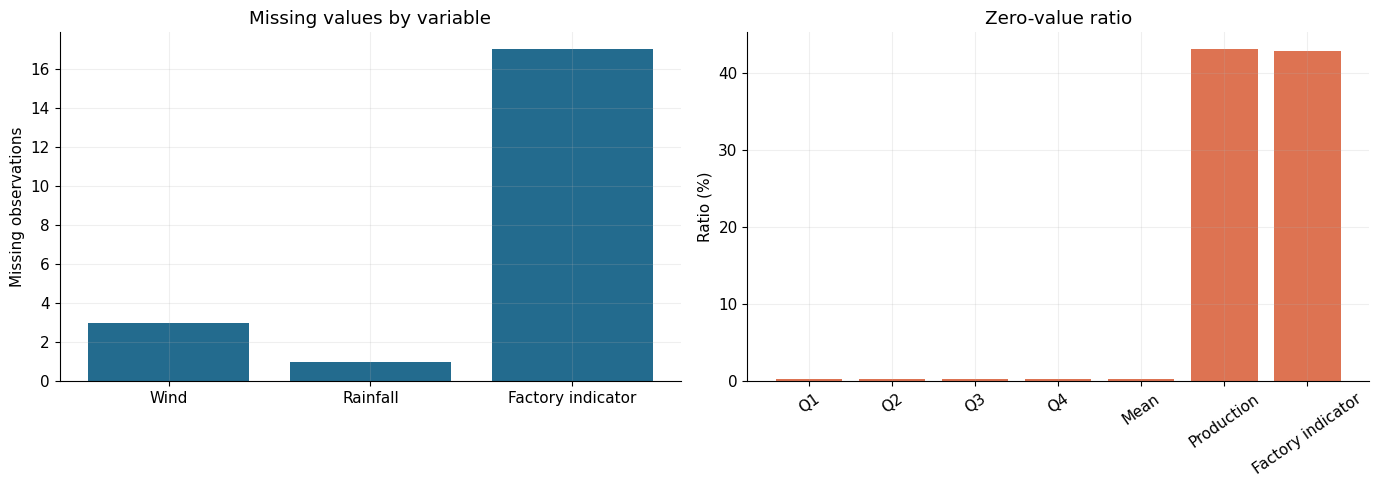

결측이 포함된 원본 행


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
552,20210124,0,73,70,69,69,70,0,9.8,3.9,66,NaN,109.8,7,24,1,0.000000,1.5
3625,20210601,1,89,94,106,105,99,80,15.3,NaN,98,0.0,191.6,2,1,6,0.203046,1.5
3626,20210601,2,102,99,107,106,104,135,15.2,NaN,96,0.0,191.6,2,1,6,0.326087,1.5
4436,20210704,20,22,23,22,22,22,0,25.4,NaN,81,24.7,191.6,7,4,7,0.000000,1.5
5754,20210828,18,0,0,0,0,0,0,25.9,0.7,81,0.2,191.6,6,28,8,NaN,1.5
5755,20210828,19,0,0,0,0,0,0,25.4,0.3,88,0.2,191.6,6,28,8,NaN,1.5
5756,20210828,20,0,0,0,0,0,0,24.8,1.2,90,0.2,191.6,6,28,8,NaN,1.5
5757,20210828,21,0,0,0,0,0,0,24.3,1.2,91,0.2,191.6,6,28,8,NaN,1.5
5758,20210828,22,0,0,0,0,0,0,24.4,1.5,89,0.2,191.6,6,28,8,NaN,1.5
5759,20210828,23,0,0,0,0,0,0,24.3,1.1,83,0.2,191.6,6,28,8,NaN,1.5


In [3]:
quality_table = pd.DataFrame(
    {
        "자료형": raw_data.dtypes.astype(str),
        "결측 개수": raw_data.isna().sum(),
        "결측률(%)": raw_data.isna().mean() * 100,
        "0값 개수": raw_data.eq(0).sum(),
        "0값 비율(%)": raw_data.eq(0).mean() * 100,
        "고유값 개수": raw_data.nunique(dropna=True),
    }
)

display(quality_table.round(3))

missing = raw_data.isna().sum()
missing = missing[missing > 0]

zero_cols = POWER_COLUMNS + ["평균", "생산량", "공장인원"]
zero_pct = raw_data[zero_cols].eq(0).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ["Wind", "Rainfall", "Factory indicator"],
    missing.reindex(["풍속", "강수량", "공장인원"]),
    color=BLUE,
)
axes[0].set(title="Missing values by variable", ylabel="Missing observations")

axes[1].bar(
    ["Q1", "Q2", "Q3", "Q4", "Mean", "Production", "Factory indicator"],
    zero_pct,
    color=ORANGE,
)
axes[1].set(title="Zero-value ratio", ylabel="Ratio (%)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
save_figure(fig, "03_missing_and_zero_values.png")

print("결측이 포함된 원본 행")
display(raw_data.loc[raw_data.isna().any(axis=1)])


### 셀 04. 날짜·시간 정합성 점검

`valid_time`은 날짜가 해석되고 시간이 0~23의 정수인 행을 표시한다. 해당 행으로 초기 `hourly_data`를 만든다. 기대되는 시간 인덱스와 비교하여 빠진 시각을 확인한다. `day`는 월요일 1~일요일 7이며 `d`, `m`은 일·월 정보이다.

In [4]:
date_parsed = pd.to_datetime(
    raw_data["날짜"].astype(str), format="%Y%m%d", errors="coerce"
)

valid_hour = raw_data["시간"].between(0, 23) & raw_data["시간"].mod(1).eq(0)

valid_time = date_parsed.notna() & valid_hour

print("잘못된 날짜 개수:", date_parsed.isna().sum())
print("잘못된 시간 개수:", (~valid_hour).sum())

print("\n시간 오류 행")
display(raw_data.loc[~valid_time, ["날짜", "시간"]])

print("\n오류 날짜별 행 수")
display(raw_data.loc[~valid_time].groupby("날짜").size().to_frame("오류 행 수"))

print("\n원본 날짜+시간 중복 초과행:", raw_data.duplicated(["날짜", "시간"]).sum())
print("완전 동일 행:", raw_data.duplicated().sum())

# 원래 날짜·시간을 이용하여 유효 시점만 구성
hourly_data = raw_data.loc[valid_time].copy()

hourly_data["timestamp"] = date_parsed.loc[valid_time] + pd.to_timedelta(
    hourly_data["시간"], unit="h"
)

hourly_data = hourly_data.sort_values("timestamp").reset_index(drop=True)

expected_hours = pd.date_range(
    date_parsed.min(), date_parsed.max() + pd.Timedelta(hours=23), freq="h"
)

missing_hours = expected_hours.difference(pd.DatetimeIndex(hourly_data["timestamp"]))

print("\n유효한 시간별 행:", len(hourly_data))
print("유효 시점 중복:", hourly_data["timestamp"].duplicated().sum())
print("시간을 확인할 수 없는 구간:", len(missing_hours))

display(pd.Series(missing_hours, name="확인 불가능한 시점"))

calendar_check = pd.Series(
    {
        "요일 불일치": (date_parsed.dt.dayofweek.add(1) != raw_data["day"]).sum(),
        "일 불일치": (date_parsed.dt.day != raw_data["d"]).sum(),
        "월 불일치": (date_parsed.dt.month != raw_data["m"]).sum(),
    }
)

display(calendar_check.to_frame("건수"))


잘못된 날짜 개수: 0
잘못된 시간 개수: 48

시간 오류 행


,날짜,시간
4632,20210713,70
4633,20210713,89
4634,20210713,90
4635,20210713,97
4636,20210713,107
4637,20210713,108
4638,20210713,112
4639,20210713,113
4640,20210713,115
4641,20210713,118



오류 날짜별 행 수


,오류 행 수
날짜,
20210713,24
20210715,24



원본 날짜+시간 중복 초과행: 5
완전 동일 행: 0

유효한 시간별 행: 6120
유효 시점 중복: 0
시간을 확인할 수 없는 구간: 48


0    2021-07-13 00:00:00
1    2021-07-13 01:00:00
2    2021-07-13 02:00:00
3    2021-07-13 03:00:00
4    2021-07-13 04:00:00
5    2021-07-13 05:00:00
6    2021-07-13 06:00:00
7    2021-07-13 07:00:00
8    2021-07-13 08:00:00
9    2021-07-13 09:00:00
10   2021-07-13 10:00:00
11   2021-07-13 11:00:00
12   2021-07-13 12:00:00
13   2021-07-13 13:00:00
14   2021-07-13 14:00:00
15   2021-07-13 15:00:00
16   2021-07-13 16:00:00
17   2021-07-13 17:00:00
18   2021-07-13 18:00:00
19   2021-07-13 19:00:00
20   2021-07-13 20:00:00
21   2021-07-13 21:00:00
22   2021-07-13 22:00:00
23   2021-07-13 23:00:00
24   2021-07-15 00:00:00
25   2021-07-15 01:00:00
26   2021-07-15 02:00:00
27   2021-07-15 03:00:00
28   2021-07-15 04:00:00
29   2021-07-15 05:00:00
30   2021-07-15 06:00:00
31   2021-07-15 07:00:00
32   2021-07-15 08:00:00
33   2021-07-15 09:00:00
34   2021-07-15 10:00:00
35   2021-07-15 11:00:00
36   2021-07-15 12:00:00
37   2021-07-15 13:00:00
38   2021-07-15 14:00:00
39   2021-07-15 15:00:00


,건수
요일 불일치,0
일 불일치,0
월 불일치,0


### 셀 05. 평균·공장인원 열의 파생식 확인

`power_mean_raw`는 네 전력값의 평균, `power_sum_raw`는 단순합이다. 평균 열의 반올림 일치와 `derived_factory = 생산량 / power_sum_raw`의 저장값 일치를 확인한다. 분모 0은 계산에서 제외하며 실제 인원 추정식으로 해석하지 않는다.

평균 열의 반올림 계산 일치: 6168 / 6168
원래 평균과 산술평균의 최대 차이: 0.5

공장인원 = 생산량 / 네 전력값의 합: 6151 / 6151
최대 절대 차이: 4.944070042256499e-09


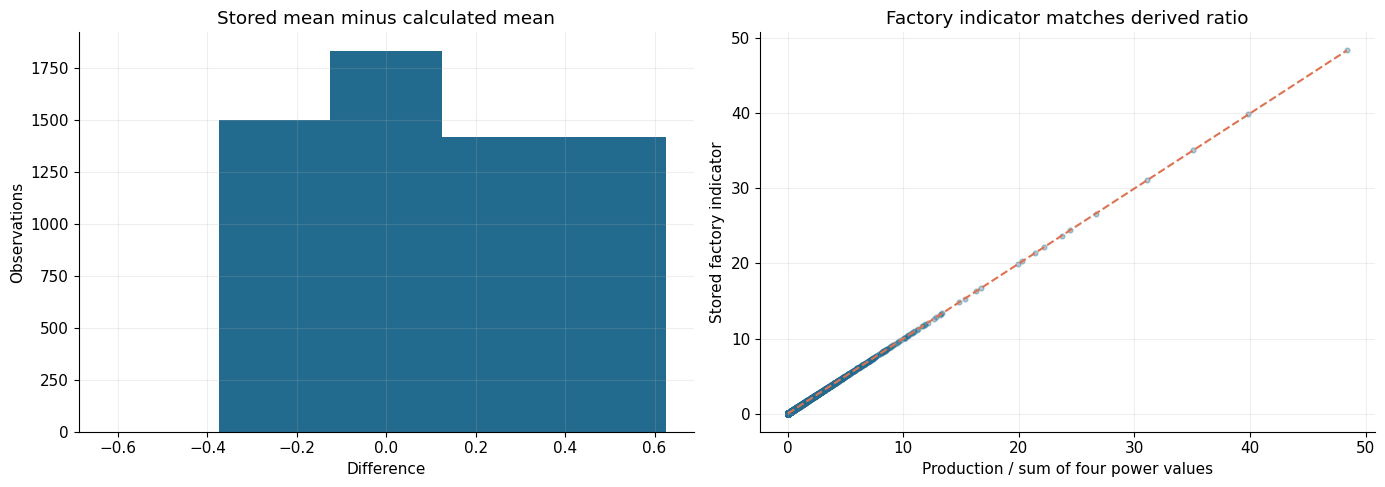

In [5]:
# 네 전력값의 산술평균과 합
power_mean_raw = raw_data[POWER_COLUMNS].mean(axis=1)
power_sum_raw = raw_data[POWER_COLUMNS].sum(axis=1)

# 양수 값에 대한 일반적인 정수 반올림
rounded_mean = np.floor(power_mean_raw + 0.5)

mean_match = np.isclose(rounded_mean, raw_data["평균"])

print("평균 열의 반올림 계산 일치:", mean_match.sum(), "/", len(raw_data))
print(
    "원래 평균과 산술평균의 최대 차이:", (raw_data["평균"] - power_mean_raw).abs().max()
)

# 공장인원 파생식 후보
derived_factory = raw_data["생산량"] / power_sum_raw.replace(0, np.nan)

comparable = derived_factory.notna() & raw_data["공장인원"].notna()

factory_match = np.isclose(
    derived_factory.loc[comparable],
    raw_data.loc[comparable, "공장인원"],
    rtol=1e-7,
    atol=1e-8,
)

print(
    "\n공장인원 = 생산량 / 네 전력값의 합:", factory_match.sum(), "/", comparable.sum()
)
print(
    "최대 절대 차이:",
    (derived_factory.loc[comparable] - raw_data.loc[comparable, "공장인원"])
    .abs()
    .max(),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    raw_data["평균"] - power_mean_raw, bins=np.arange(-0.625, 0.751, 0.25), color=BLUE
)
axes[0].set(
    title="Stored mean minus calculated mean",
    xlabel="Difference",
    ylabel="Observations",
)

x = derived_factory.loc[comparable]
y = raw_data.loc[comparable, "공장인원"]

axes[1].scatter(x, y, s=12, alpha=0.35, color=BLUE)

line_max = max(x.max(), y.max())
axes[1].plot([0, line_max], [0, line_max], linestyle="--", color=ORANGE)
axes[1].set(
    title="Factory indicator matches derived ratio",
    xlabel="Production / sum of four power values",
    ylabel="Stored factory indicator",
)

plt.tight_layout()
save_figure(fig, "05_derived_columns.png")


### 셀 06. 생산·전력의 0값과 인건비 패턴

생산량 0 여부와 네 전력값이 모두 0인지 교차 집계한다. 공장인원 결측 구간의 생산·전력 상태 및 시간별 인건비 열의 분포를 확인한다. 인건비 열의 값만으로 실제 투입 인원이나 비용을 산정하지 않는다.

col_0,네 전력 모두 0,전력 양수 구간 존재
생산량,,
생산량 = 0,17,2640
생산량 > 0,0,3511



공장인원 결측 행의 생산량·전력


,날짜,시간,15분,30분,45분,60분,생산량,공장인원
5754,20210828,18,0,0,0,0,0,NaN
5755,20210828,19,0,0,0,0,0,NaN
5756,20210828,20,0,0,0,0,0,NaN
5757,20210828,21,0,0,0,0,0,NaN
5758,20210828,22,0,0,0,0,0,NaN
5759,20210828,23,0,0,0,0,0,NaN
5760,20210829,0,0,0,0,0,0,NaN
5761,20210829,1,0,0,0,0,0,NaN
5762,20210829,2,0,0,0,0,0,NaN
5763,20210829,3,0,0,0,0,0,NaN



시간대별 인건비 값


인건비,1.0,1.5
시간,,
0,0,255
1,0,255
2,0,255
3,0,255
4,0,255
5,0,255
6,0,255
7,0,255
8,0,255


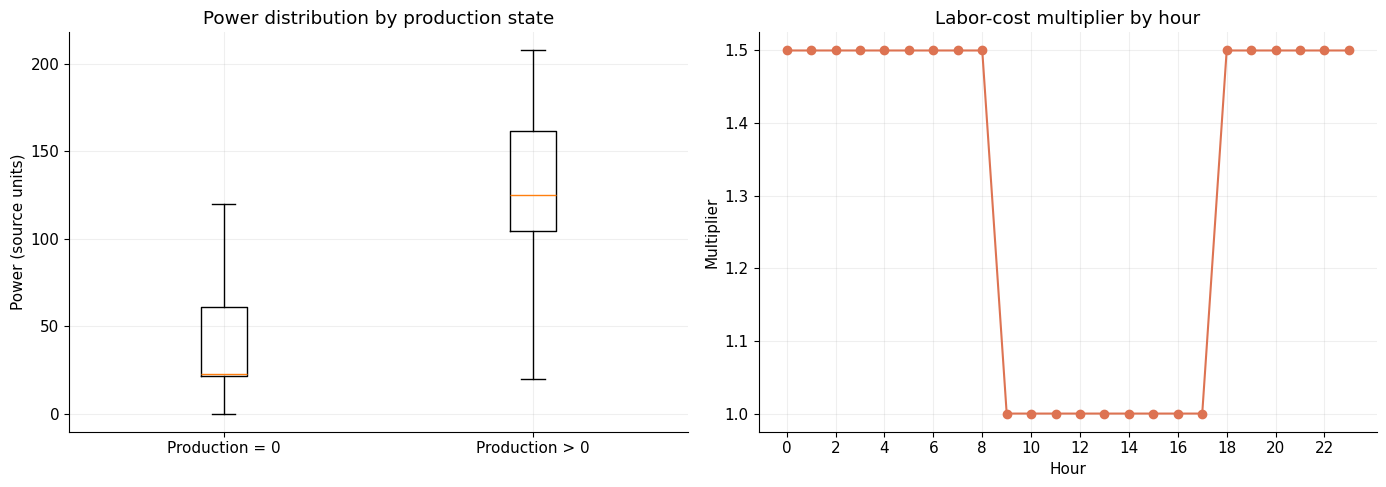

In [6]:
production_zero = raw_data["생산량"].eq(0)
all_power_zero = raw_data[POWER_COLUMNS].eq(0).all(axis=1)

state_table = pd.crosstab(
    production_zero.map({True: "생산량 = 0", False: "생산량 > 0"}),
    all_power_zero.map({True: "네 전력 모두 0", False: "전력 양수 구간 존재"}),
)

display(state_table)

print("\n공장인원 결측 행의 생산량·전력")
display(
    raw_data.loc[
        raw_data["공장인원"].isna(),
        ["날짜", "시간"] + POWER_COLUMNS + ["생산량", "공장인원"],
    ]
)

print("\n시간대별 인건비 값")
display(pd.crosstab(hourly_data["시간"], hourly_data["인건비"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

groups = [power_mean_raw.loc[production_zero], power_mean_raw.loc[~production_zero]]

axes[0].boxplot(
    groups, tick_labels=["Production = 0", "Production > 0"], showfliers=False
)
axes[0].set(
    title="Power distribution by production state", ylabel="Power (source units)"
)

labor_by_hour = hourly_data.groupby("시간")["인건비"].agg(["min", "max"])

axes[1].plot(labor_by_hour.index, labor_by_hour["min"], marker="o", color=ORANGE)
axes[1].set(
    title="Labor-cost multiplier by hour",
    xlabel="Hour",
    ylabel="Multiplier",
    xticks=range(0, 24, 2),
)

plt.tight_layout()
save_figure(fig, "06_production_state_and_labor.png")


### 셀 07. 초기 15분 전력 표 구성

`hourly_data`에 `power_mean`, `power_max`를 추가하고 `quarter_data`로 변환한다. `quarter`는 원본 전력 열 이름, `power`는 해당 구간 전력값, `timestamp`는 구간 시작 시각이다. 시간별 생산량·기상 값은 네 행에 반복된다.

In [7]:
hourly_data = add_hourly_power_statistics(hourly_data)
quarter_data = to_quarter_data(hourly_data)

print("시간별 유효 행:", len(hourly_data))
print("15분 관측:", len(quarter_data))
print("15분 시점 중복:", quarter_data["timestamp"].duplicated().sum())
display(quarter_data.head(12))


시간별 유효 행: 6120
15분 관측: 24480
15분 시점 중복: 0


,timestamp,날짜,시간,day,m,생산량,기온,풍속,습도,강수량,quarter,power
0,2021-01-01 00:00:00,20210101,0,5,1,0,-3.2,2.4,71,0.0,15분,62
1,2021-01-01 00:15:00,20210101,0,5,1,0,-3.2,2.4,71,0.0,30분,61
2,2021-01-01 00:30:00,20210101,0,5,1,0,-3.2,2.4,71,0.0,45분,61
3,2021-01-01 00:45:00,20210101,0,5,1,0,-3.2,2.4,71,0.0,60분,61
4,2021-01-01 01:00:00,20210101,1,5,1,0,-4.5,1.5,77,0.0,15분,96
5,2021-01-01 01:15:00,20210101,1,5,1,0,-4.5,1.5,77,0.0,30분,93
6,2021-01-01 01:30:00,20210101,1,5,1,0,-4.5,1.5,77,0.0,45분,116
7,2021-01-01 01:45:00,20210101,1,5,1,0,-4.5,1.5,77,0.0,60분,113
8,2021-01-01 02:00:00,20210101,2,5,1,0,-3.9,2.6,58,0.0,15분,106
9,2021-01-01 02:15:00,20210101,2,5,1,0,-3.9,2.6,58,0.0,30분,96


### 셀 08. 전력 분포와 탐색적 고전력 기준

히스토그램·상자그림·경험적 누적분포로 전력 분포를 확인한다. `high_power`는 `power >= EDA_PEAK_THRESHOLD` 여부이다. 같은 값이 반복되면 기준 이상의 비율이 정확히 5%가 되지 않을 수 있다.

,전력 통계
count,24480.000
mean,92.979
std,58.052
min,0.000
25%,23.000
50%,104.000
75%,143.000
90%,170.000
95%,179.000
99%,194.000


EDA 고전력 기준: 179.0
고전력 관측: 1340
고전력 비율: 5.47%


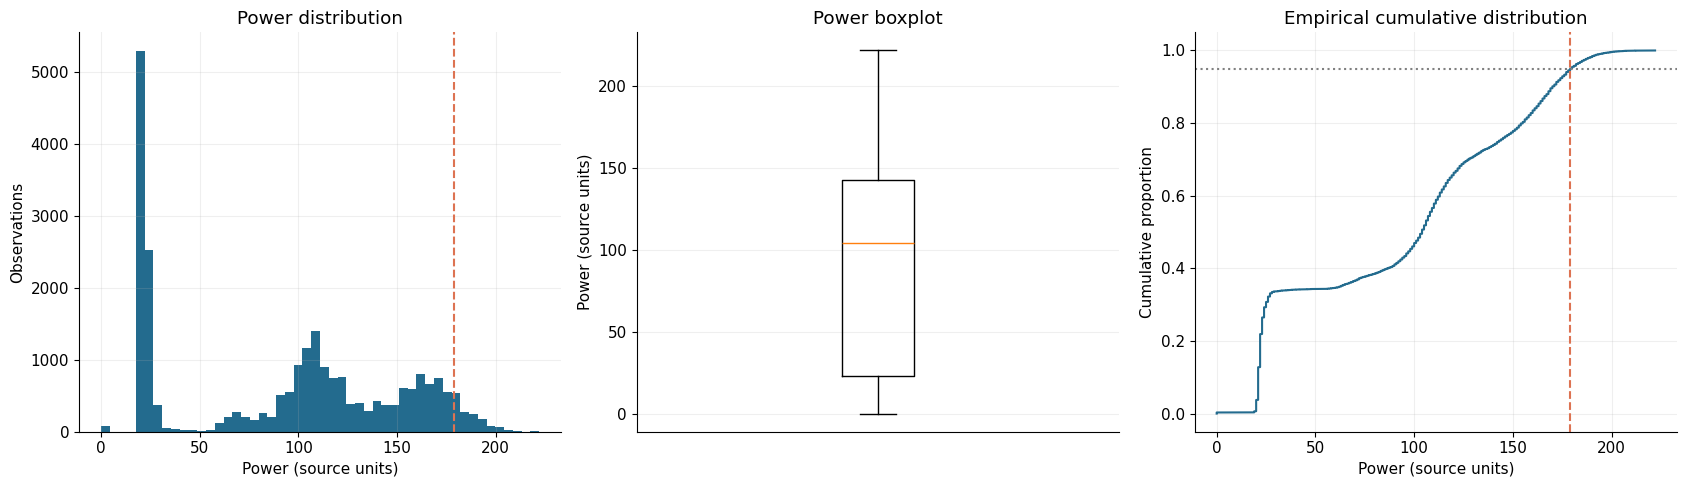

In [8]:
power_summary = quarter_data["power"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

display(power_summary.to_frame("전력 통계").round(3))

# 전체 유효 기간을 이용한 탐색적 기준
EDA_PEAK_THRESHOLD = quarter_data["power"].quantile(0.95)

quarter_data["high_power"] = quarter_data["power"] >= EDA_PEAK_THRESHOLD

print("EDA 고전력 기준:", EDA_PEAK_THRESHOLD)
print("고전력 관측:", quarter_data["high_power"].sum())
print("고전력 비율:", f'{quarter_data["high_power"].mean() * 100:.2f}%')

sorted_power = np.sort(quarter_data["power"].to_numpy())
cumulative = np.arange(1, len(sorted_power) + 1) / len(sorted_power)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].hist(quarter_data["power"], bins=50, color=BLUE)
axes[0].axvline(EDA_PEAK_THRESHOLD, color=ORANGE, linestyle="--")
axes[0].set(
    title="Power distribution", xlabel="Power (source units)", ylabel="Observations"
)

axes[1].boxplot(quarter_data["power"], showfliers=True)
axes[1].set(title="Power boxplot", ylabel="Power (source units)", xticks=[])

axes[2].plot(sorted_power, cumulative, color=BLUE)
axes[2].axvline(EDA_PEAK_THRESHOLD, color=ORANGE, linestyle="--")
axes[2].axhline(0.95, color="gray", linestyle=":")
axes[2].set(
    title="Empirical cumulative distribution",
    xlabel="Power (source units)",
    ylabel="Cumulative proportion",
)

plt.tight_layout()
save_figure(fig, "08_power_distribution.png")


### 셀 09. 전체 시계열과 날짜별 관측 수

`power_grid`는 일정한 15분 격자로 재색인한 전력 시계열이다. 제외 날짜는 결측으로 남겨 앞뒤 관측이 연속인 것처럼 연결되지 않도록 한다. `daily_power`는 일별 평균·최대·유효 관측 수이며 하루 기대 관측 수는 96개이다.

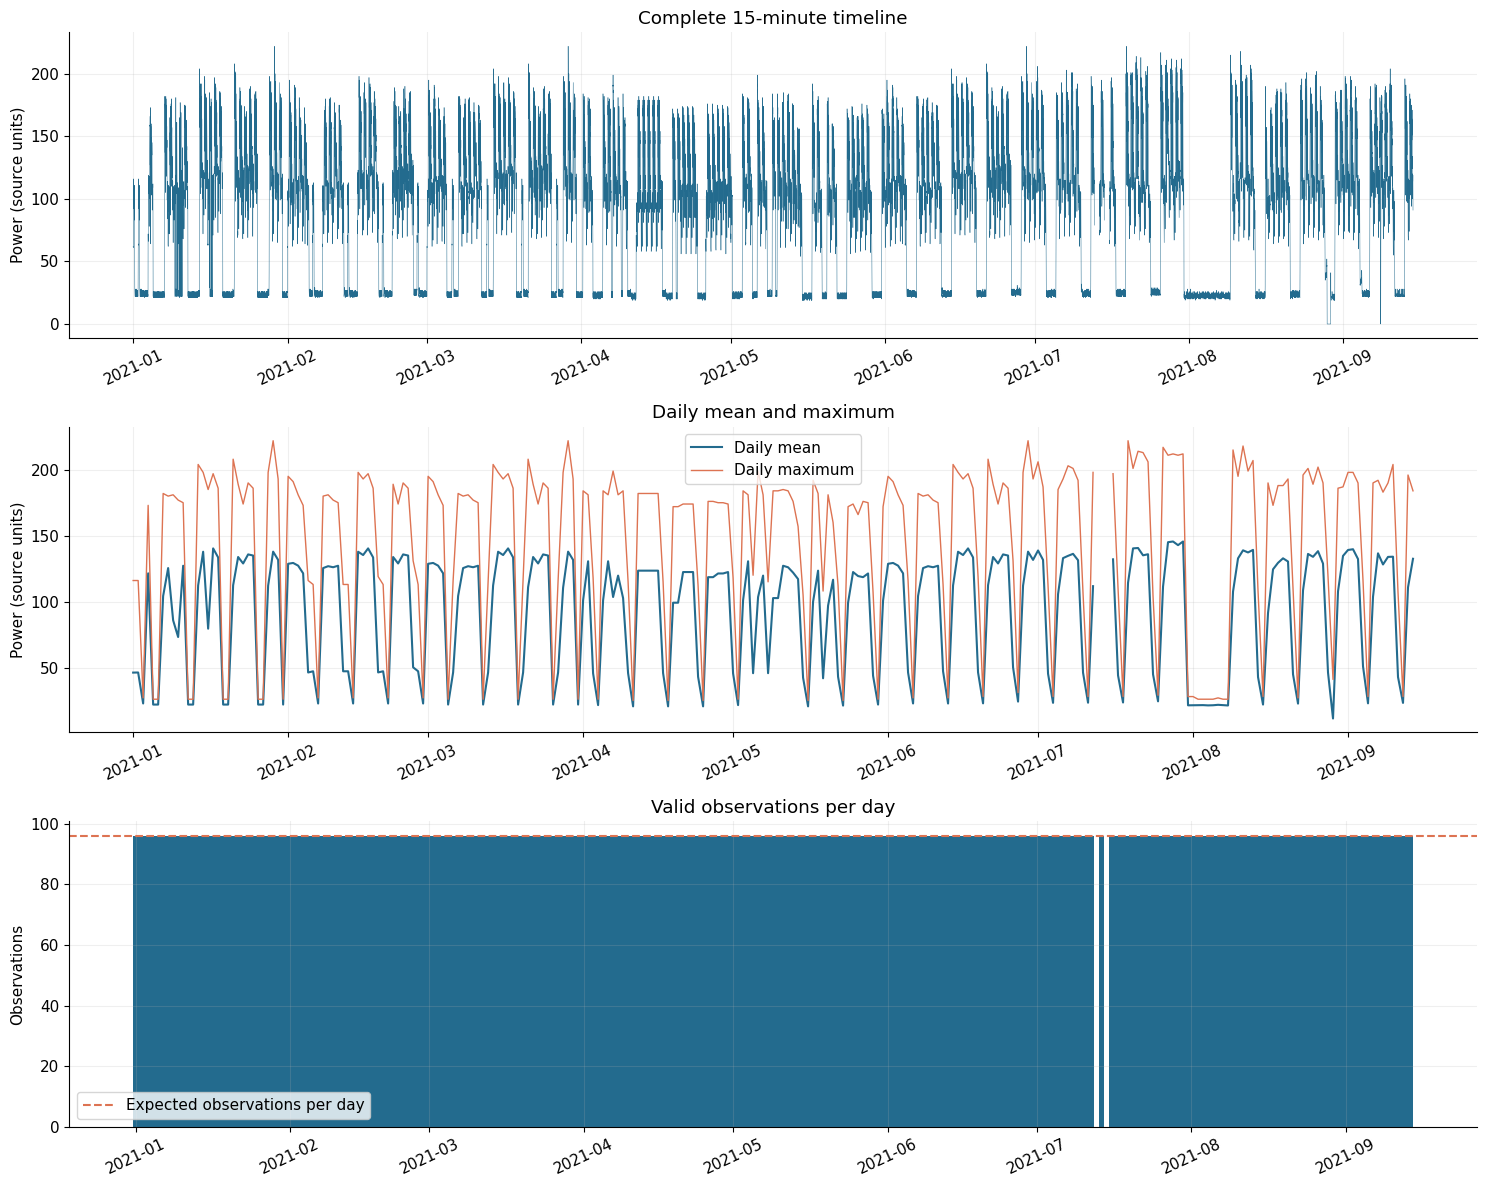

In [9]:
power_series = quarter_data.set_index("timestamp")["power"]

full_15_index = pd.date_range(
    power_series.index.min(), power_series.index.max(), freq="15min"
)

# 오류 날짜에 해당하는 구간은 NaN
power_grid = power_series.reindex(full_15_index)

daily_power = power_grid.resample("D").agg(["mean", "max", "count"])

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(power_grid.index, power_grid.values, linewidth=0.35, color=BLUE)
axes[0].set(title="Complete 15-minute timeline", ylabel="Power (source units)")

axes[1].plot(daily_power.index, daily_power["mean"], label="Daily mean", color=BLUE)
axes[1].plot(
    daily_power.index,
    daily_power["max"],
    label="Daily maximum",
    color=ORANGE,
    linewidth=1,
)
axes[1].set(title="Daily mean and maximum", ylabel="Power (source units)")
axes[1].legend()

axes[2].bar(daily_power.index, daily_power["count"], color=BLUE, width=1)
axes[2].axhline(96, color=ORANGE, linestyle="--", label="Expected observations per day")
axes[2].set(title="Valid observations per day", ylabel="Observations")
axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
save_figure(fig, "09_power_timeline.png")


### 셀 10. 시간·요일별 전력과 고전력 빈도

`hour_stats`, `weekday_stats`에서 평균과 고전력 비율을 계산한다. `high_rate`는 0~1의 비율이며 그림에서는 100을 곱해 백분율로 나타낸다. 요일×시간 히트맵으로 반복되는 운영 패턴을 확인하여 달력 피처의 필요성을 검토한다.

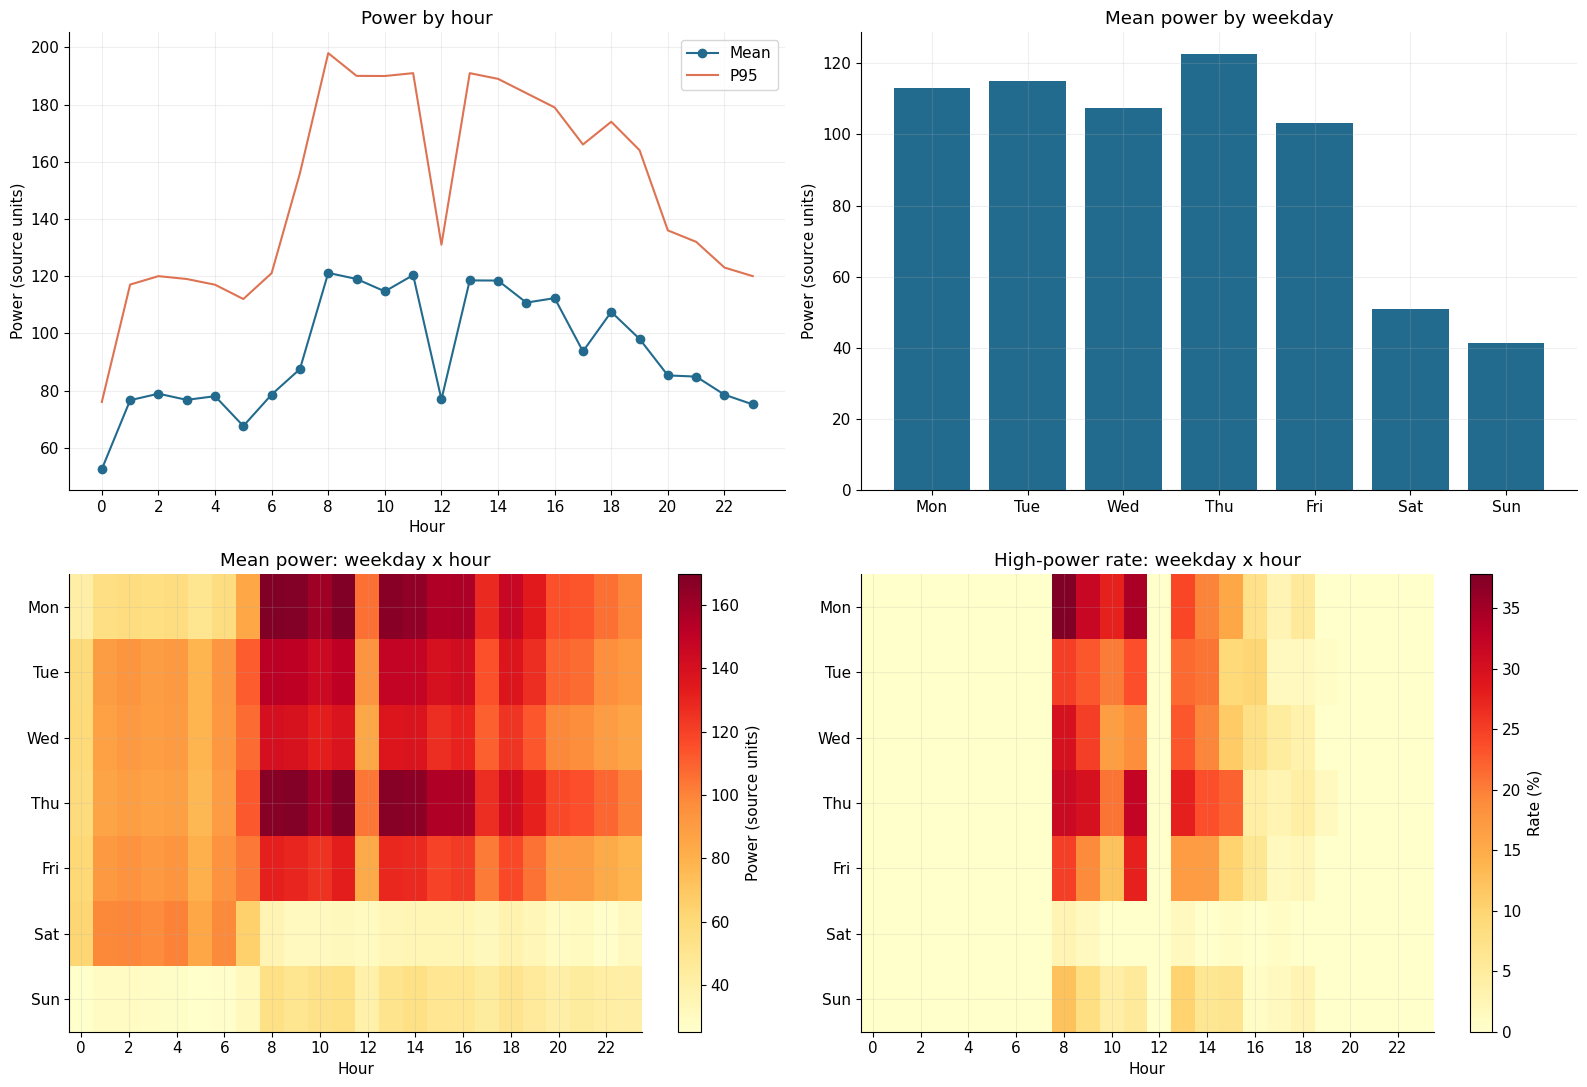

,observations,mean_power,p95_power,high_count,high_rate
시간,,,,,
0,1020,52.485,76.00,0,0.000
1,1020,76.608,117.05,0,0.000
2,1020,78.878,120.00,0,0.000
3,1020,76.728,119.00,0,0.000
4,1020,78.017,117.00,0,0.000
5,1020,67.573,112.00,0,0.000
6,1020,78.593,121.05,0,0.000
7,1020,87.508,156.00,0,0.000
8,1020,121.132,198.00,238,0.233


,observations,mean_power,high_count,high_rate
day,,,,
1,3552,113.173,306,0.086
2,3456,114.903,225,0.065
3,3456,107.431,230,0.067
4,3360,122.571,281,0.084
5,3552,103.119,203,0.057
6,3552,50.998,10,0.003
7,3552,41.241,85,0.024


In [10]:
hour_stats = quarter_data.groupby("시간").agg(
    observations=("power", "size"),
    mean_power=("power", "mean"),
    p95_power=("power", lambda x: x.quantile(0.95)),
    high_count=("high_power", "sum"),
    high_rate=("high_power", "mean"),
)

weekday_stats = quarter_data.groupby("day").agg(
    observations=("power", "size"),
    mean_power=("power", "mean"),
    high_count=("high_power", "sum"),
    high_rate=("high_power", "mean"),
)

weekday_hour_mean = quarter_data.pivot_table(
    index="day", columns="시간", values="power", aggfunc="mean"
).reindex(range(1, 8))

weekday_hour_risk = (
    quarter_data.pivot_table(
        index="day", columns="시간", values="high_power", aggfunc="mean"
    ).reindex(range(1, 8))
    * 100
)


fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].plot(
    hour_stats.index, hour_stats["mean_power"], label="Mean", marker="o", color=BLUE
)
axes[0, 0].plot(hour_stats.index, hour_stats["p95_power"], label="P95", color=ORANGE)
axes[0, 0].set(
    title="Power by hour",
    xlabel="Hour",
    ylabel="Power (source units)",
    xticks=range(0, 24, 2),
)
axes[0, 0].legend()

axes[0, 1].bar(weekday_stats.index, weekday_stats["mean_power"], color=BLUE)
axes[0, 1].set(
    title="Mean power by weekday",
    ylabel="Power (source units)",
    xticks=range(1, 8),
    xticklabels=DAY_LABELS,
)

for ax, table, title, label in [
    (
        axes[1, 0],
        weekday_hour_mean,
        "Mean power: weekday x hour",
        "Power (source units)",
    ),
    (axes[1, 1], weekday_hour_risk, "High-power rate: weekday x hour", "Rate (%)"),
]:
    image = ax.imshow(table, aspect="auto", cmap="YlOrRd")
    ax.set(
        title=title,
        xlabel="Hour",
        xticks=range(0, 24, 2),
        yticks=range(7),
        yticklabels=DAY_LABELS,
    )
    fig.colorbar(image, ax=ax, label=label)

plt.tight_layout()
save_figure(fig, "10_hour_and_weekday.png")

display(hour_stats.round(3))
display(weekday_stats.round(3))


### 셀 11. 월별 전력 분포

`month_stats`에서 월별 관측 수·평균·최대·고전력 비율을 확인한다. 9월은 14일까지의 부분 기간이며 초기 7월 분석에서는 오류 날짜 이틀이 제외되어 있다. 관측 수 차이가 있으므로 건수와 비율을 함께 해석한다.

,observations,mean_power,maximum_power,high_count,high_rate
m,,,,,
1,2976,83.252,222,141,0.047
2,2688,91.513,198,82,0.031
3,2976,99.841,222,167,0.056
4,2880,94.586,199,46,0.016
5,2976,85.941,199,38,0.013
6,2880,102.859,222,167,0.058
7,2784,101.353,222,375,0.135
8,2976,81.093,218,231,0.078
9,1344,102.193,204,93,0.069


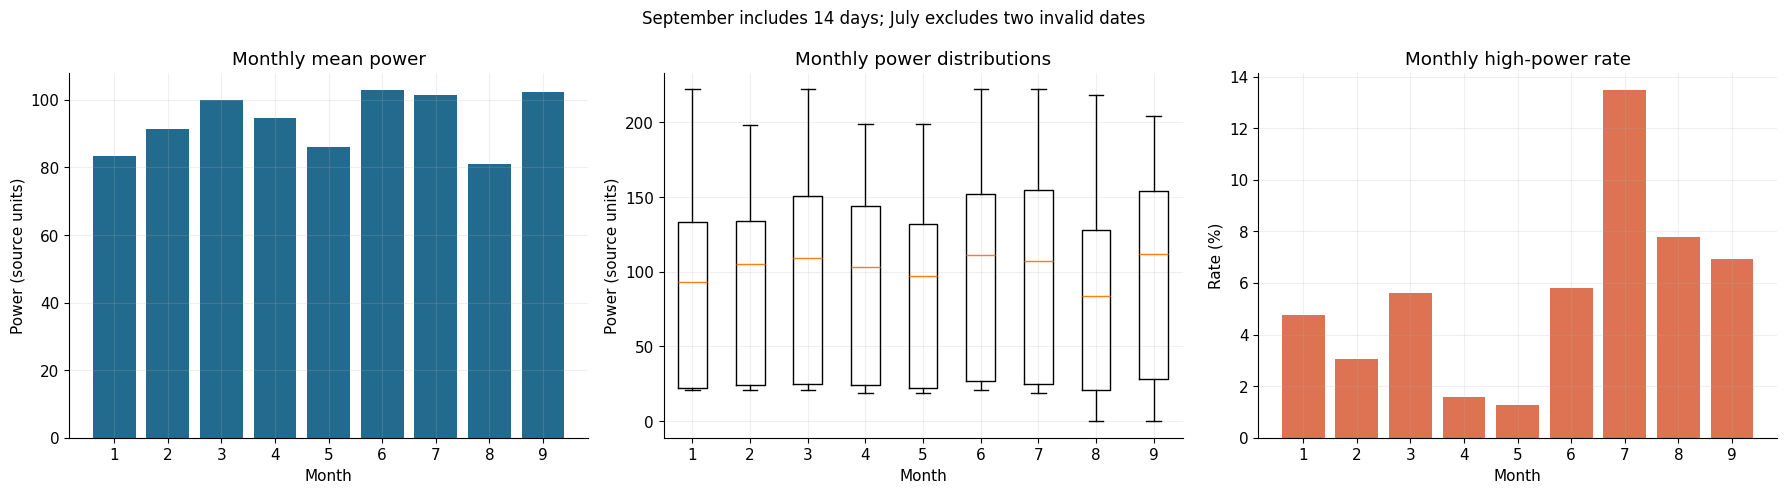

In [11]:
month_stats = quarter_data.groupby("m").agg(
    observations=("power", "size"),
    mean_power=("power", "mean"),
    maximum_power=("power", "max"),
    high_count=("high_power", "sum"),
    high_rate=("high_power", "mean"),
)

display(month_stats.round(3))

month_values = [
    quarter_data.loc[quarter_data["m"].eq(month), "power"] for month in range(1, 10)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(month_stats.index, month_stats["mean_power"], color=BLUE)
axes[0].set(
    title="Monthly mean power",
    xlabel="Month",
    ylabel="Power (source units)",
    xticks=range(1, 10),
)

axes[1].boxplot(month_values, showfliers=False)
axes[1].set(
    title="Monthly power distributions", xlabel="Month", ylabel="Power (source units)"
)

axes[2].bar(month_stats.index, month_stats["high_rate"] * 100, color=ORANGE)
axes[2].set(
    title="Monthly high-power rate",
    xlabel="Month",
    ylabel="Rate (%)",
    xticks=range(1, 10),
)

fig.suptitle("September includes 14 days; July excludes two invalid dates", fontsize=12)

plt.tight_layout()
save_figure(fig, "11_monthly_power.png")


### 셀 12. 생산량·기상과 전력의 상관관계

시간별 `power_mean`과 생산량·기상 변수의 Pearson 및 Spearman 상관계수를 비교한다. Pearson은 선형 관계, Spearman은 순위의 단조 관계를 요약한다. 결측은 pandas의 쌍별 유효 관측으로 처리하며 인과관계를 뜻하지 않는다.

,Pearson,Spearman
Power,1.0000,1.0000
Production,0.5237,0.7586
Temperature,0.0458,0.0634
Wind,0.1240,0.1337
Humidity,-0.0908,-0.1031
Rainfall,-0.0105,0.0179


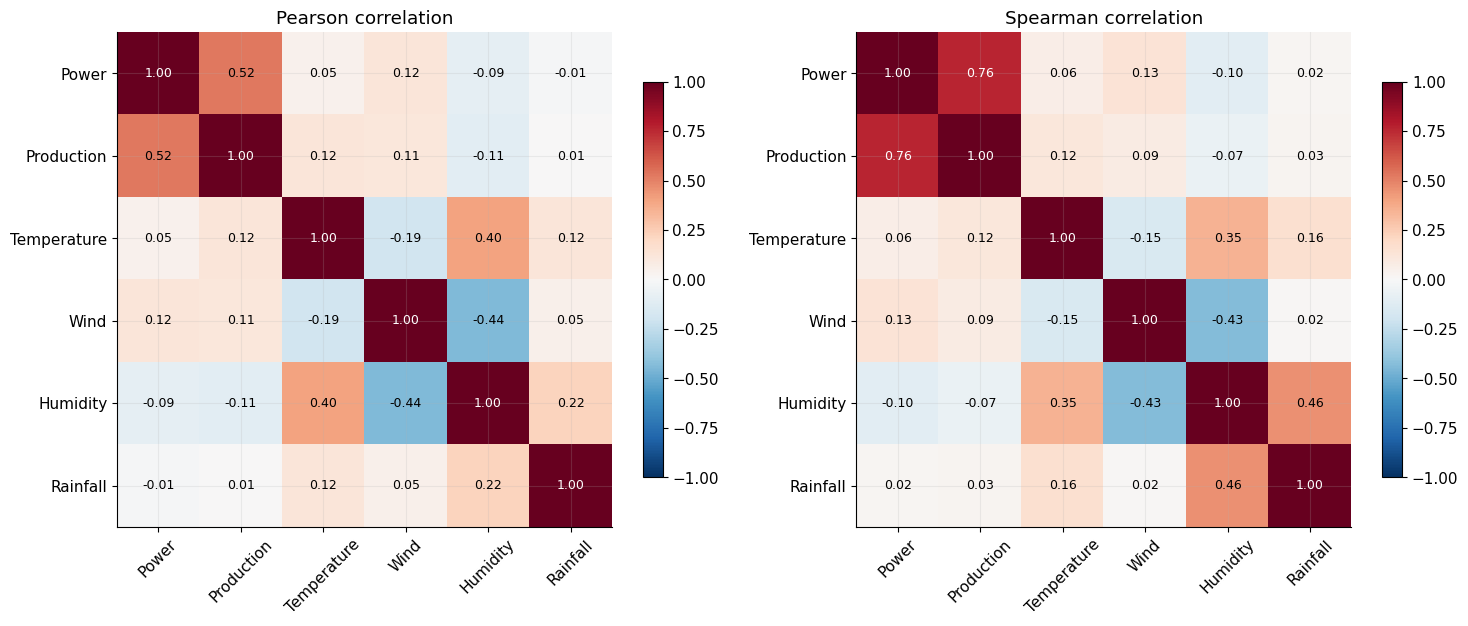

In [12]:
corr_columns = ["power_mean", "생산량", "기온", "풍속", "습도", "강수량"]

english_names = {
    "power_mean": "Power",
    "생산량": "Production",
    "기온": "Temperature",
    "풍속": "Wind",
    "습도": "Humidity",
    "강수량": "Rainfall",
}

corr_data = hourly_data[corr_columns].rename(columns=english_names)

pearson_corr = corr_data.corr(method="pearson")
spearman_corr = corr_data.corr(method="spearman")

target_corr = pd.DataFrame(
    {"Pearson": pearson_corr["Power"], "Spearman": spearman_corr["Power"]}
)

display(target_corr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, matrix, title in [
    (axes[0], pearson_corr, "Pearson correlation"),
    (axes[1], spearman_corr, "Spearman correlation"),
]:
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")

    ax.set(
        title=title,
        xticks=range(len(matrix)),
        yticks=range(len(matrix)),
        xticklabels=matrix.columns,
        yticklabels=matrix.index,
    )
    ax.tick_params(axis="x", rotation=45)

    for row in range(len(matrix)):
        for col in range(len(matrix)):
            value = matrix.iloc[row, col]
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) > 0.6 else "black",
                fontsize=9,
            )

    fig.colorbar(image, ax=ax, shrink=0.8)

plt.tight_layout()
save_figure(fig, "12_correlation.png")


### 셀 13. 산점도와 생산량 구간별 분포

생산량·기온과 평균 전력의 관계를 확인한다. `symlog`는 0을 유지하며 큰 생산량의 표시 범위를 압축하는 시각화 축이고 모델 입력 변환이 아니다. 생산량 구간은 탐색용이며 표의 전력 통계는 시간별 평균 전력에 관한 값이다.

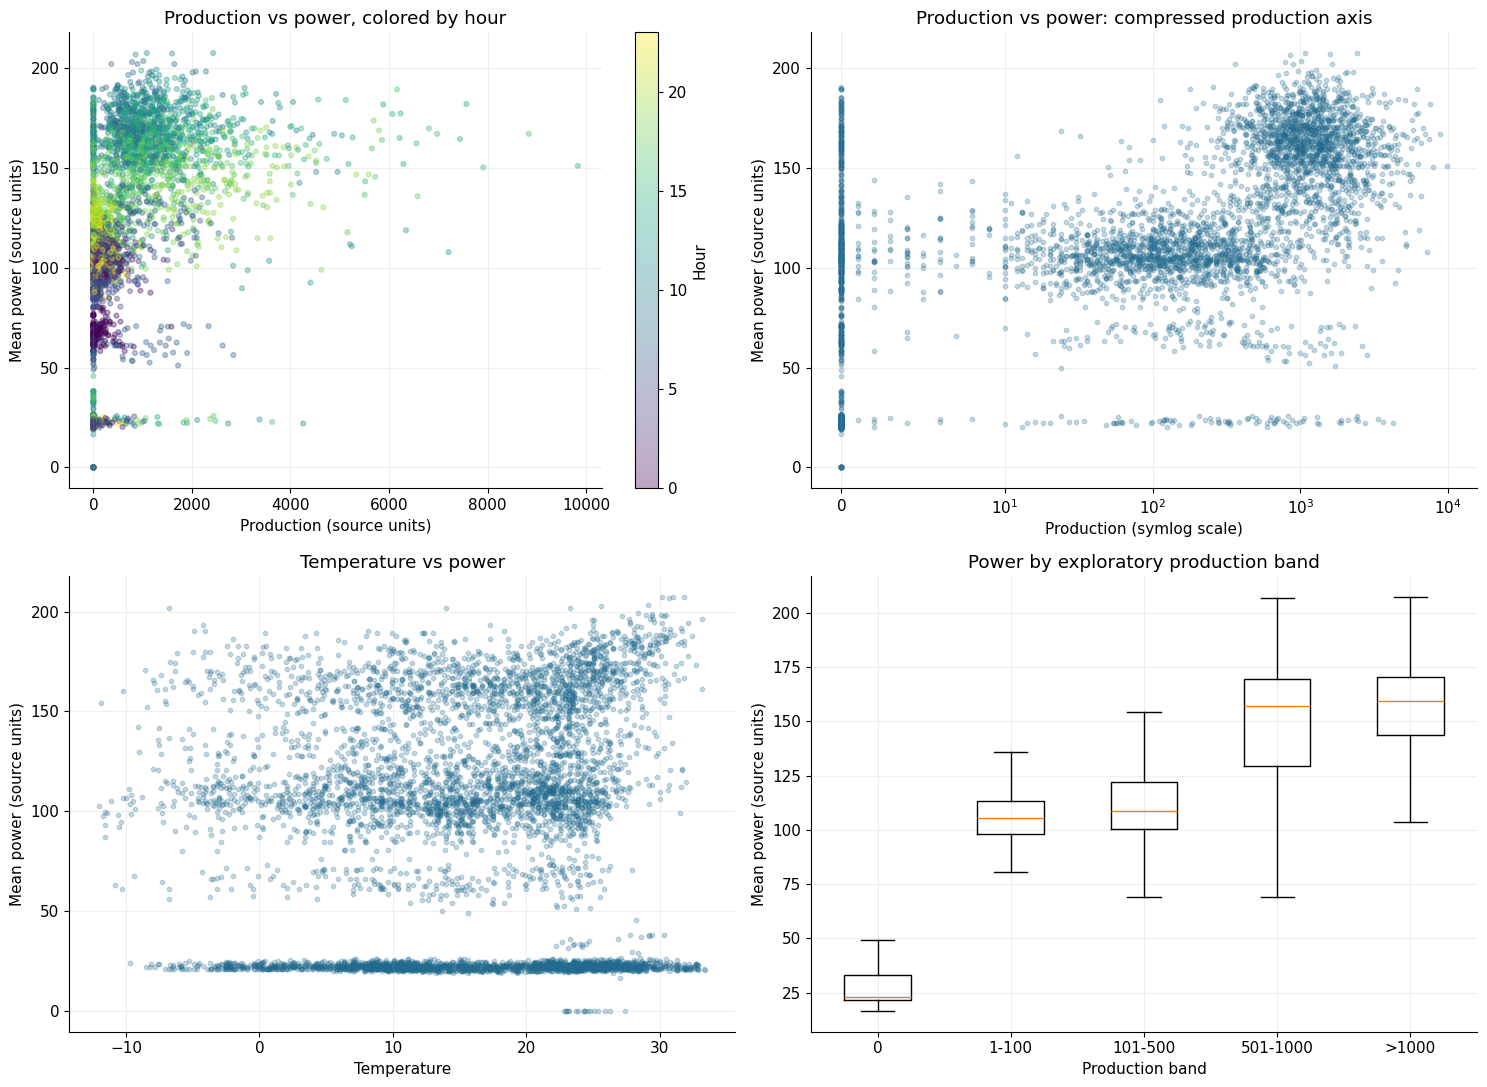

,observations,mean_power,median_power,p95_power
production_band,,,,
0,2609,44.444,22.750,143.40
1-100,788,102.789,105.625,128.75
101-500,977,112.168,108.750,171.05
501-1000,688,145.752,157.000,184.75
>1000,1058,153.319,159.500,186.50


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

scatter = axes[0, 0].scatter(
    hourly_data["생산량"],
    hourly_data["power_mean"],
    c=hourly_data["시간"],
    cmap="viridis",
    s=12,
    alpha=0.35,
)
axes[0, 0].set(
    title="Production vs power, colored by hour",
    xlabel="Production (source units)",
    ylabel="Mean power (source units)",
)
fig.colorbar(scatter, ax=axes[0, 0], label="Hour")

axes[0, 1].scatter(
    hourly_data["생산량"], hourly_data["power_mean"], s=10, alpha=0.25, color=BLUE
)
axes[0, 1].set_xscale("symlog", linthresh=10)
axes[0, 1].set(
    title="Production vs power: compressed production axis",
    xlabel="Production (symlog scale)",
    ylabel="Mean power (source units)",
)

axes[1, 0].scatter(
    hourly_data["기온"], hourly_data["power_mean"], s=10, alpha=0.25, color=BLUE
)
axes[1, 0].set(
    title="Temperature vs power",
    xlabel="Temperature",
    ylabel="Mean power (source units)",
)

production_bins = [-0.1, 0, 100, 500, 1000, np.inf]
production_labels = ["0", "1-100", "101-500", "501-1000", ">1000"]

production_groups = pd.cut(
    hourly_data["생산량"], bins=production_bins, labels=production_labels
)

group_values = [
    hourly_data.loc[production_groups.eq(label), "power_mean"]
    for label in production_labels
]

axes[1, 1].boxplot(group_values, showfliers=False)
axes[1, 1].set(
    title="Power by exploratory production band",
    xlabel="Production band",
    ylabel="Mean power (source units)",
    xticks=range(1, 6),
    xticklabels=production_labels,
)

plt.tight_layout()
save_figure(fig, "13_production_and_weather.png")

production_band_table = (
    hourly_data.assign(production_band=production_groups)
    .groupby("production_band", observed=True)
    .agg(
        observations=("power_mean", "size"),
        mean_power=("power_mean", "mean"),
        median_power=("power_mean", "median"),
        p95_power=("power_mean", lambda x: x.quantile(0.95)),
    )
)

display(production_band_table.round(3))


### 셀 14. 고전력 집중 조건과 사례

시간·요일·생산량 0 여부에 따른 고전력 빈도를 확인한다. 지정 시간대 집중 비율은 전체 고전력 관측 중 해당 시간대가 차지하는 몫이다. 높은 관측값과 생산량 0·고전력 사례를 제시하되 원인을 확정하지 않는다.

,observations,mean_power,high_count,high_rate
production_state,,,,
Production = 0,10436,44.4444,108,0.0103
Production > 0,14044,129.0446,1232,0.0877


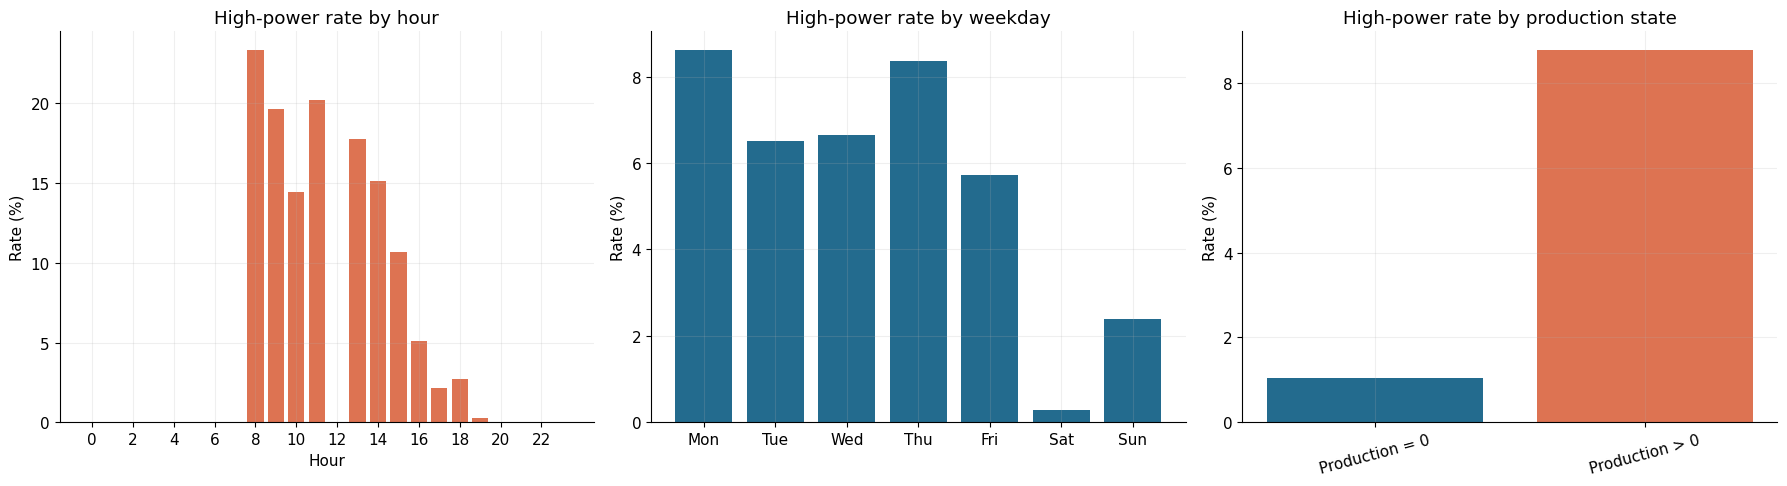

08-11시, 13-15시의 고전력 집중 비율: 92.16%

전력값이 가장 높은 관측 20개


,timestamp,quarter,power,생산량,기온,day
2721,2021-01-29 08:15:00,30분,222,364,-6.8,5
8385,2021-03-29 08:15:00,30분,222,1644,14.0,1
17217,2021-06-29 08:15:00,30분,222,893,23.3,2
18957,2021-07-19 11:15:00,30분,222,1280,28.4,1
21154,2021-08-11 08:30:00,45분,218,783,25.6,3
19617,2021-07-26 08:15:00,30분,217,805,29.4,1
20962,2021-08-09 08:30:00,45분,215,749,23.6,1
19143,2021-07-21 09:45:00,60분,214,1013,29.1,3
19233,2021-07-22 08:15:00,30분,213,709,27.7,4
19823,2021-07-28 11:45:00,60분,212,2429,31.0,3



생산량 0인데 고전력인 사례


,timestamp,power,생산량,기온,day
823,2021-01-09 13:45:00,181,0,-3.7,6
1473,2021-01-16 08:15:00,185,0,2.3,6
1474,2021-01-16 08:30:00,180,0,2.3,6
1502,2021-01-16 15:30:00,180,0,6.6,6
1569,2021-01-17 08:15:00,193,0,-4.1,7
1570,2021-01-17 08:30:00,197,0,-4.1,7
1571,2021-01-17 08:45:00,193,0,-4.1,7
1572,2021-01-17 09:00:00,188,0,-3.7,7
1573,2021-01-17 09:15:00,180,0,-3.7,7
1575,2021-01-17 09:45:00,179,0,-3.7,7


In [14]:
production_state_stats = (
    quarter_data.assign(
        production_state=np.where(
            quarter_data["생산량"].eq(0), "Production = 0", "Production > 0"
        )
    )
    .groupby("production_state")
    .agg(
        observations=("power", "size"),
        mean_power=("power", "mean"),
        high_count=("high_power", "sum"),
        high_rate=("high_power", "mean"),
    )
)

display(production_state_stats.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(hour_stats.index, hour_stats["high_rate"] * 100, color=ORANGE)
axes[0].set(
    title="High-power rate by hour",
    xlabel="Hour",
    ylabel="Rate (%)",
    xticks=range(0, 24, 2),
)

axes[1].bar(weekday_stats.index, weekday_stats["high_rate"] * 100, color=BLUE)
axes[1].set(
    title="High-power rate by weekday",
    ylabel="Rate (%)",
    xticks=range(1, 8),
    xticklabels=DAY_LABELS,
)

axes[2].bar(
    production_state_stats.index,
    production_state_stats["high_rate"] * 100,
    color=[BLUE, ORANGE],
)
axes[2].set(title="High-power rate by production state", ylabel="Rate (%)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
save_figure(fig, "14_high_power_conditions.png")

risk_hours = [8, 9, 10, 11, 13, 14, 15]

high_total = quarter_data["high_power"].sum()

high_in_risk_hours = quarter_data.loc[
    quarter_data["시간"].isin(risk_hours), "high_power"
].sum()

print(
    "08-11시, 13-15시의 고전력 집중 비율:",
    f"{high_in_risk_hours / high_total * 100:.2f}%",
)

print("\n전력값이 가장 높은 관측 20개")
display(
    quarter_data.nlargest(20, "power")[
        ["timestamp", "quarter", "power", "생산량", "기온", "day"]
    ]
)

print("\n생산량 0인데 고전력인 사례")
display(
    quarter_data.loc[
        quarter_data["생산량"].eq(0) & quarter_data["high_power"],
        ["timestamp", "power", "생산량", "기온", "day"],
    ].head(20)
)


### 셀 15. 일별 전력 프로파일의 반복

`daily_profiles`는 날짜별 24시간×4개 전력값을 담는다. `profile_id`는 완전히 같은 전력 프로파일의 식별자이다. 전력 프로파일이 같다고 기상·생산량을 포함한 원본 전체 행이 같다는 의미는 아니므로 반복 날짜를 자동 삭제하지 않는다.

유효한 날짜: 255
고유 전력 프로파일: 140
반복 그룹에 속한 날짜: 160
중복 초과 날짜: 115


,같은 패턴을 가진 날짜 수
프로파일 ID,
4,15
1,7
45,6
26,6
27,5
47,5
19,4
18,4
11,4


가장 자주 반복되는 프로파일의 날짜 예시:
[20210105, 20210106, 20210112, 20210113, 20210119, 20210120, 20210126, 20210127, 20210131, 20210305, 20210312, 20210319, 20210326, 20210331, 20210530]


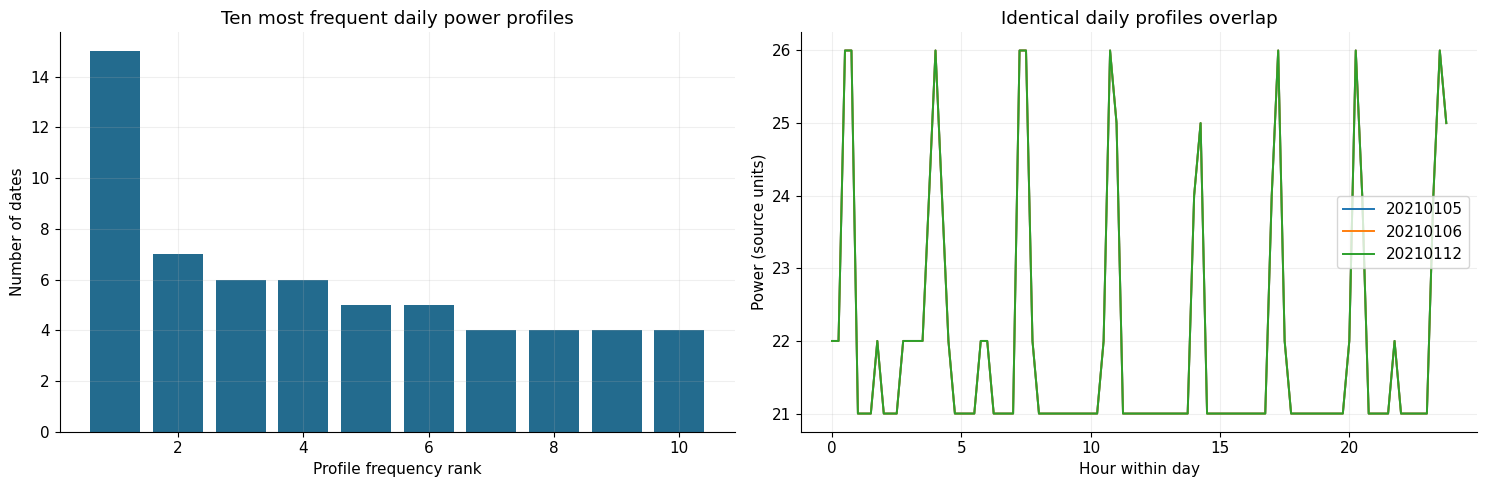

In [15]:
daily_profiles = hourly_data.pivot(index="날짜", columns="시간", values=POWER_COLUMNS)

repeated_days = daily_profiles.duplicated(keep=False)

print("유효한 날짜:", len(daily_profiles))
print("고유 전력 프로파일:", len(daily_profiles.drop_duplicates()))
print("반복 그룹에 속한 날짜:", repeated_days.sum())
print("중복 초과 날짜:", daily_profiles.duplicated().sum())

# 프로파일별 식별자 부여
profile_keys = pd.Series(
    [tuple(row) for row in daily_profiles.to_numpy()], index=daily_profiles.index
)

profile_ids = pd.Series(
    pd.factorize(profile_keys)[0], index=daily_profiles.index, name="profile_id"
)

profile_frequency = profile_ids.value_counts()

display(
    profile_frequency.head(10)
    .rename_axis("프로파일 ID")
    .to_frame("같은 패턴을 가진 날짜 수")
)

# 가장 자주 반복되는 프로파일의 날짜 예시
most_common_profile = profile_frequency.index[0]

example_dates = profile_ids.index[profile_ids.eq(most_common_profile)].tolist()

print("가장 자주 반복되는 프로파일의 날짜 예시:")
print(example_dates[:20])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, 11), profile_frequency.head(10).to_numpy(), color=BLUE)
axes[0].set(
    title="Ten most frequent daily power profiles",
    xlabel="Profile frequency rank",
    ylabel="Number of dates",
)

# 같은 프로파일을 가진 날짜 최대 3개를 겹쳐 그림
for date in example_dates[:3]:
    values = (
        hourly_data.loc[hourly_data["날짜"].eq(date)]
        .sort_values("시간")[POWER_COLUMNS]
        .to_numpy()
        .ravel()
    )

    axes[1].plot(np.arange(96) / 4, values, label=str(date), linewidth=1.4)

axes[1].set(
    title="Identical daily profiles overlap",
    xlabel="Hour within day",
    ylabel="Power (source units)",
)
axes[1].legend()

plt.tight_layout()
save_figure(fig, "15_repeated_daily_profiles.png")


### 셀 16. 지연 자기상관

15분·1시간·1일·1주 전력의 자기상관과 일주일 범위의 지연 상관을 확인한다. `lag_steps`는 15분 관측 단위의 지연 수이므로 1·4·96·672가 각각 해당한다. 원본 값끼리의 지연 상관으로 추세·운영 주기가 함께 반영되며 예측 성능을 보장하지 않는다.

,자기상관계수
15 minutes,0.9698
1 hour,0.8787
1 day,0.3743
1 week,0.7382


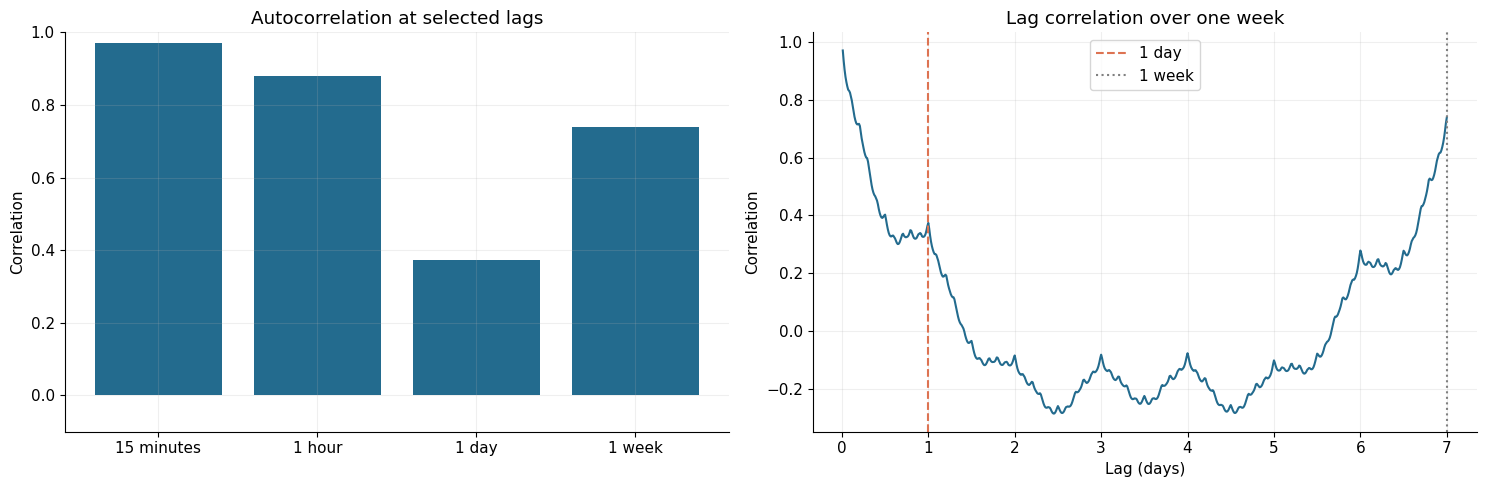

In [16]:
lag_steps = {"15 minutes": 1, "1 hour": 4, "1 day": 96, "1 week": 672}

autocorrelation_table = pd.Series(
    {name: power_grid.autocorr(lag=steps) for name, steps in lag_steps.items()}
)

display(autocorrelation_table.to_frame("자기상관계수").round(4))

# 일주일 범위의 지연 자기상관
lags = np.arange(1, 673)

acf_values = np.array([power_grid.autocorr(lag=int(lag)) for lag in lags])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(autocorrelation_table.index, autocorrelation_table.values, color=BLUE)
axes[0].set(
    title="Autocorrelation at selected lags", ylabel="Correlation", ylim=(-0.1, 1)
)

axes[1].plot(lags / 96, acf_values, color=BLUE)
axes[1].axvline(1, color=ORANGE, linestyle="--", label="1 day")
axes[1].axvline(7, color="gray", linestyle=":", label="1 week")
axes[1].set(
    title="Lag correlation over one week", xlabel="Lag (days)", ylabel="Correlation"
)
axes[1].legend()

plt.tight_layout()
save_figure(fig, "16_autocorrelation.png")


## 2. 합의된 전처리와 후속 점검

이하에서는 복원 날짜를 포함한 자료를 사용한다. 앞의 초기 시간·요일·월별 표를 자동 재계산하는 단계는 아니다.

### 셀 17. 팀 합의 전처리와 검증

`clean_data`에서 두 날짜의 시간을 원본 행 순서대로 복원하고 합의된 결측 처리를 적용한다. `source_row`는 원본 행 위치, `original_hour`는 복원 전 시간, `hour_restored`는 복원 대상 표시이다. `wind_imputed`, `rain_imputed`, `factory_imputed`는 원래 결측이었던 행을 표시한다. 풍속 보간은 오프라인 EDA 처리이며 실제 예측에 사용할 때는 미래 관측 이용 여부를 별도 검토한다.

In [17]:
# 기존 셀 1에서 만든 df_raw를 사용
clean_data = raw_data.copy().reset_index(drop=True)

# 원래 값과 처리 이력 보존
clean_data["source_row"] = np.arange(len(clean_data))
clean_data["original_hour"] = clean_data["시간"]

clean_data["hour_restored"] = False
clean_data["wind_imputed"] = clean_data["풍속"].isna()
clean_data["rain_imputed"] = clean_data["강수량"].isna()
clean_data["factory_imputed"] = clean_data["공장인원"].isna()


# 날짜별 원본 행 순서대로 0~23시 복원
for date in RESTORE_DATES:
    idx = clean_data.index[clean_data["날짜"].eq(date)]

    if len(idx) != 24:
        raise ValueError(f"{date}: 행 수가 {len(idx)}개이므로 복원 기준 확인 필요")

    clean_data.loc[idx, "시간"] = np.arange(24)
    clean_data.loc[idx, "hour_restored"] = True

# 날짜·시간으로 실제 시각 구성
clean_data["timestamp"] = pd.to_datetime(
    clean_data["날짜"].astype(str), format="%Y%m%d", errors="raise"
) + pd.to_timedelta(clean_data["시간"], unit="h")

clean_data = clean_data.sort_values("timestamp").reset_index(drop=True)

# 시간 인덱스 기반 풍속 보간
wind_interpolated = clean_data.set_index("timestamp")["풍속"].interpolate(method="time")

clean_data["풍속"] = wind_interpolated.to_numpy()

# 팀 합의에 따른 결측 대체
clean_data["강수량"] = clean_data["강수량"].fillna(0)
clean_data["공장인원"] = clean_data["공장인원"].fillna(0)

# 처리 후 검증
assert len(clean_data) == len(raw_data)
assert clean_data["시간"].between(0, 23).all()
assert clean_data["시간"].mod(1).eq(0).all()
assert not clean_data["timestamp"].duplicated().any()

time_gaps = clean_data["timestamp"].diff().dropna() != pd.Timedelta(hours=1)

assert not time_gaps.any()
assert not clean_data[raw_data.columns].isna().any().any()

print("시간별 행:", len(clean_data))
print("복원한 행:", clean_data["hour_restored"].sum())
print("시점 중복:", clean_data["timestamp"].duplicated().sum())
print("시간 간격 오류:", time_gaps.sum())

print("\n보간한 풍속")
display(clean_data.loc[clean_data["wind_imputed"], ["timestamp", "풍속"]])

print("\n처리 전후 결측 개수")
display(
    pd.DataFrame(
        {
            "처리 전": raw_data.isna().sum(),
            "처리 후": clean_data[raw_data.columns].isna().sum(),
        }
    )
)


시간별 행: 6168
복원한 행: 48
시점 중복: 0
시간 간격 오류: 0

보간한 풍속


,timestamp,풍속
3625,2021-06-01 01:00:00,0.633333
3626,2021-06-01 02:00:00,0.666667
4436,2021-07-04 20:00:00,1.850000



처리 전후 결측 개수


,처리 전,처리 후
날짜,0,0
시간,0,0
15분,0,0
30분,0,0
45분,0,0
60분,0,0
평균,0,0
생산량,0,0
기온,0,0
풍속,3,0


### 셀 18. 전처리 후 15분 표와 고전력 기준

전처리 결과로 `hourly_data`·`quarter_data`를 다시 구성하고 전체 기간의 탐색적 P95를 재계산한다. 원본의 두 날짜를 포함한 관측 수와 중복·15분 간격을 확인한다. 이후 셀은 이 자료와 기준을 사용한다.

In [18]:
hourly_data = add_hourly_power_statistics(clean_data)
quarter_data = to_quarter_data(
    hourly_data, extra_columns=("source_row", "hour_restored")
)

# 복원한 두 날짜를 포함한 전체 기간의 탐색적 기준을 다시 계산한다.
EDA_PEAK_THRESHOLD = quarter_data["power"].quantile(0.95)
quarter_data["high_power"] = quarter_data["power"].ge(EDA_PEAK_THRESHOLD)

# 자료 크기는 입력에 따라 검증하며 특정 관측 수를 하드코딩하지 않는다.
assert len(quarter_data) == len(raw_data) * 4
assert quarter_data["timestamp"].diff().dropna().eq(pd.Timedelta(minutes=15)).all()

print("15분 관측:", len(quarter_data))
print("탐색적 고전력 기준:", EDA_PEAK_THRESHOLD)
print("고전력 관측:", quarter_data["high_power"].sum())
print("고전력 비율:", f'{quarter_data["high_power"].mean() * 100:.2f}%')
display(
    quarter_data["power"]
    .describe(percentiles=[0.90, 0.95, 0.99])
    .to_frame("전력 통계")
    .round(3)
)


15분 관측: 24672
탐색적 고전력 기준: 180.0
고전력 관측: 1248
고전력 비율: 5.06%


,전력 통계
count,24672.000
mean,93.312
std,58.033
min,0.000
50%,104.000
90%,170.000
95%,180.000
99%,194.000
max,222.000


### 셀 19. 시간 복원 날짜의 상세 확인

7월 12~16일 평균·최대 전력과 생산량, 복원 두 날짜의 15분 패턴을 확인한다. 음영은 복원 대상 날짜를 표시한다. 시간값 복원 가정의 타당성을 살펴보는 자료이며 측정 시각의 외부 증명이 아니다.

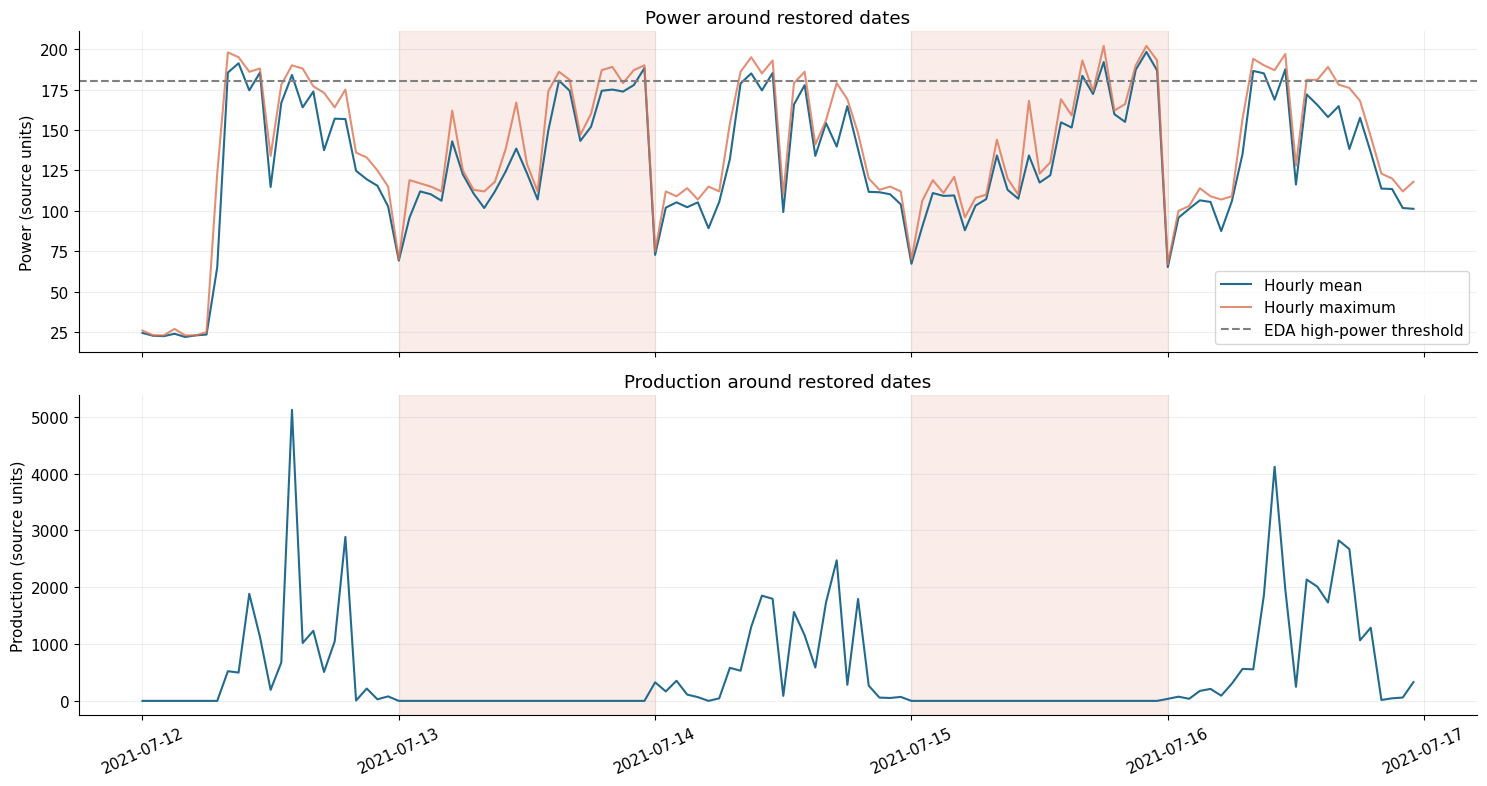

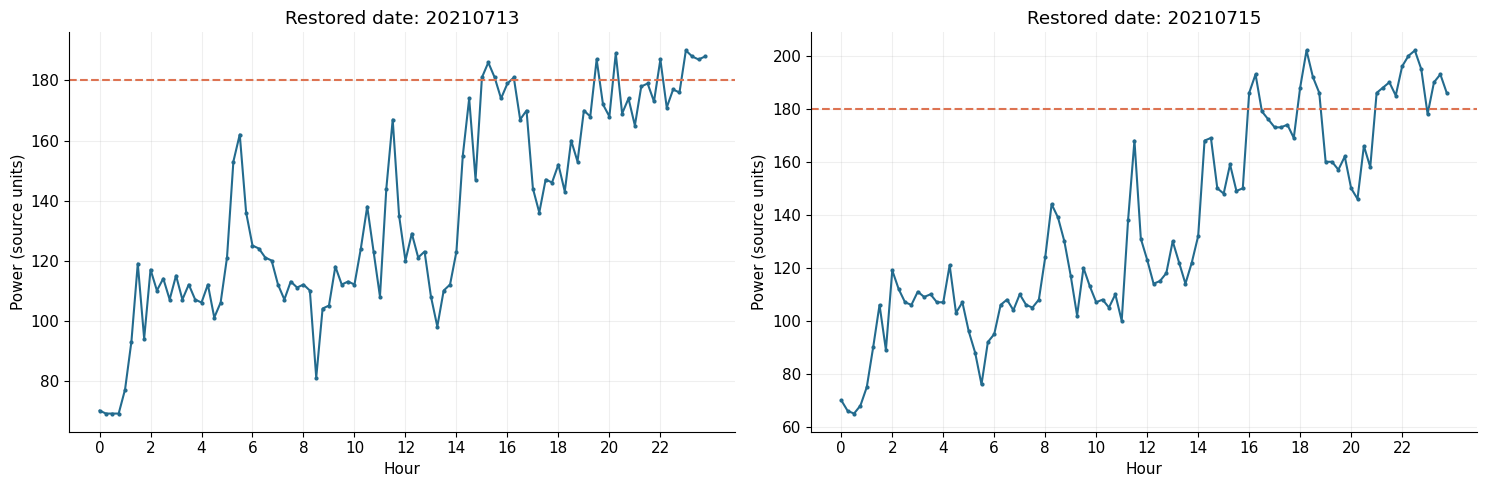

복원한 날짜의 시간별 값


,timestamp,original_hour,power_mean,power_max,생산량
4632,2021-07-13 00:00:00,70,69.25,70,0
4633,2021-07-13 01:00:00,89,95.75,119,0
4634,2021-07-13 02:00:00,90,112.00,117,0
4635,2021-07-13 03:00:00,97,110.25,115,0
4636,2021-07-13 04:00:00,107,106.25,112,0
4637,2021-07-13 05:00:00,108,143.00,162,0
4638,2021-07-13 06:00:00,112,122.50,125,0
4639,2021-07-13 07:00:00,113,110.75,113,0
4640,2021-07-13 08:00:00,115,101.75,112,0
4641,2021-07-13 09:00:00,118,112.00,118,0


In [19]:
# 7/12~7/16 주변 구간
window = hourly_data.loc[
    hourly_data["timestamp"].between("2021-07-12 00:00", "2021-07-16 23:00")
].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(window["timestamp"], window["power_mean"], label="Hourly mean", color=BLUE)

axes[0].plot(
    window["timestamp"],
    window["power_max"],
    label="Hourly maximum",
    color=ORANGE,
    alpha=0.8,
)

axes[0].axhline(
    EDA_PEAK_THRESHOLD, color="gray", linestyle="--", label="EDA high-power threshold"
)

axes[0].set(title="Power around restored dates", ylabel="Power (source units)")
axes[0].legend()

axes[1].plot(window["timestamp"], window["생산량"], color=BLUE)
axes[1].set(
    title="Production around restored dates", ylabel="Production (source units)"
)

for ax in axes:
    for date in ["2021-07-13", "2021-07-15"]:
        start = pd.Timestamp(date)
        ax.axvspan(start, start + pd.Timedelta(days=1), color=ORANGE, alpha=0.12)

axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
save_figure(fig, "19_restored_dates.png")

# 복원한 두 날짜의 상세 일중 패턴
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, date in zip(axes, RESTORE_DATES):
    day_data = quarter_data.loc[quarter_data["날짜"].eq(date)].sort_values("timestamp")

    within_day_hour = (
        day_data["timestamp"].dt.hour + day_data["timestamp"].dt.minute / 60
    )

    ax.plot(within_day_hour, day_data["power"], color=BLUE, marker=".", markersize=4)

    ax.axhline(EDA_PEAK_THRESHOLD, color=ORANGE, linestyle="--")

    ax.set(
        title=f"Restored date: {date}",
        xlabel="Hour",
        ylabel="Power (source units)",
        xticks=range(0, 24, 2),
    )

plt.tight_layout()
save_figure(fig, "19_restored_dates_2.png")

print("복원한 날짜의 시간별 값")
display(
    hourly_data.loc[
        hourly_data["hour_restored"],
        ["timestamp", "original_hour", "power_mean", "power_max", "생산량"],
    ]
)


### 셀 20. 연속 0전력 구간과 결측 처리 확인

`zero_runs`는 네 전력이 모두 0인 시간별 연속 구간이다. `last_hour`는 마지막 행의 시작 시각, `interval_end`는 해당 행 구간의 종료 시각이다. 8월 28일 18시~29일 10시 행의 전력·생산량·공장인원 상태를 확인하며 가동 중단 여부는 추정으로 남긴다.

네 전력값이 모두 0인 연속 구간


,start,last_hour,duration_hours,production_sum,interval_end
2,2021-08-28 18:00:00,2021-08-29 10:00:00,17,0,2021-08-29 11:00:00


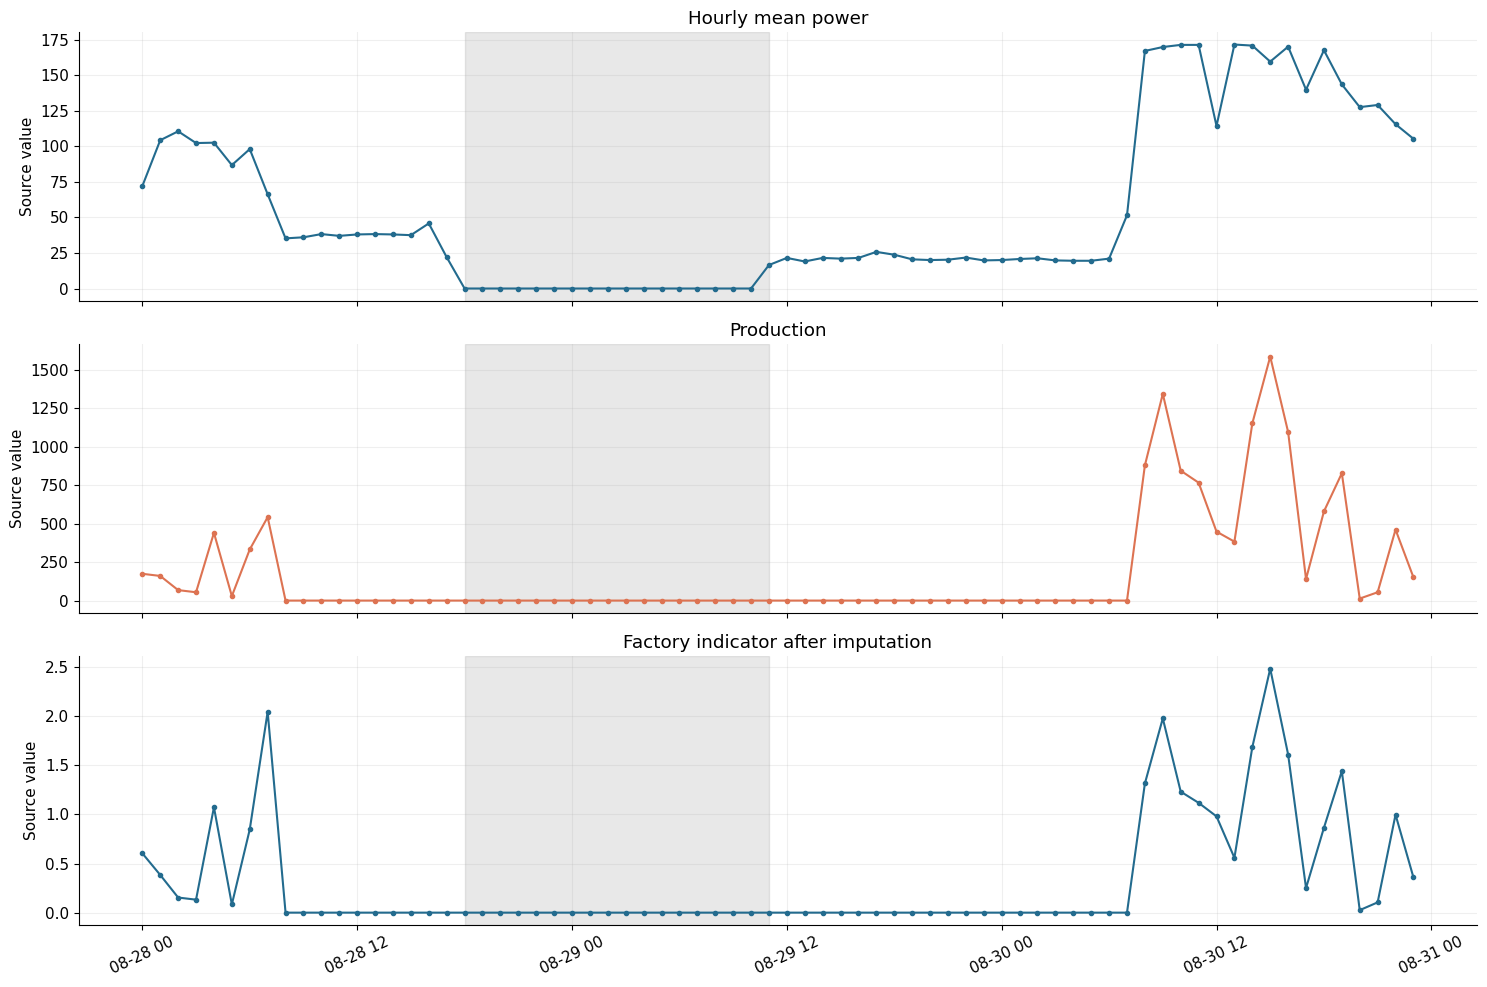

0전력 구간 전후 값


,timestamp,power_mean,생산량,공장인원,factory_imputed
5752,2021-08-28 16:00:00,45.75,0,0.0,False
5753,2021-08-28 17:00:00,22.00,0,0.0,False
5754,2021-08-28 18:00:00,0.00,0,0.0,True
5755,2021-08-28 19:00:00,0.00,0,0.0,True
5756,2021-08-28 20:00:00,0.00,0,0.0,True
5757,2021-08-28 21:00:00,0.00,0,0.0,True
5758,2021-08-28 22:00:00,0.00,0,0.0,True
5759,2021-08-28 23:00:00,0.00,0,0.0,True
5760,2021-08-29 00:00:00,0.00,0,0.0,True
5761,2021-08-29 01:00:00,0.00,0,0.0,True


In [20]:
all_zero = hourly_data[POWER_COLUMNS].eq(0).all(axis=1)

# 상태가 바뀌거나 시간 연속성이 끊기면 새 구간
new_run = all_zero.ne(all_zero.shift()) | hourly_data["timestamp"].diff().ne(
    pd.Timedelta(hours=1)
)

run_id = new_run.cumsum()

zero_runs = (
    hourly_data.loc[all_zero]
    .groupby(run_id.loc[all_zero])
    .agg(
        start=("timestamp", "min"),
        last_hour=("timestamp", "max"),
        duration_hours=("timestamp", "size"),
        production_sum=("생산량", "sum"),
    )
)

zero_runs["interval_end"] = zero_runs["last_hour"] + pd.Timedelta(hours=1)

print("네 전력값이 모두 0인 연속 구간")
display(zero_runs)

window = hourly_data.loc[
    hourly_data["timestamp"].between("2021-08-28 00:00", "2021-08-30 23:00")
]

zero_start = pd.Timestamp("2021-08-28 18:00")
zero_end = pd.Timestamp("2021-08-29 11:00")

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for col, title, color, ax in [
    ("power_mean", "Hourly mean power", BLUE, axes[0]),
    ("생산량", "Production", ORANGE, axes[1]),
    ("공장인원", "Factory indicator after imputation", BLUE, axes[2]),
]:
    ax.plot(window["timestamp"], window[col], marker=".", color=color)
    ax.axvspan(zero_start, zero_end, color="gray", alpha=0.18)
    ax.set(title=title, ylabel="Source value")

axes[-1].tick_params(axis="x", rotation=25)

plt.tight_layout()
save_figure(fig, "20_zero_power_interval.png")

print("0전력 구간 전후 값")
display(
    hourly_data.loc[
        hourly_data["timestamp"].between("2021-08-28 16:00", "2021-08-29 12:00"),
        ["timestamp", "power_mean", "생산량", "공장인원", "factory_imputed"],
    ]
)


### 셀 21. 생산량과 전력이 어긋나는 사례

생산량 0·P95 이상 전력, 생산량 양수·30 이하 전력 사례를 집계한다. `case_masks`는 유형별 조건이고 집계의 기본 단위는 15분 전력 관측이다. 시간별 생산량이 네 행에 반복되므로 독립 생산 사건 수와 구분한다.

,15분 관측 수,관련 시간 수,관련 날짜 수,복원 날짜 관측 수
유형,,,,
"Production=0, high power",128,62,15,28
"Production>0, low power",419,129,36,0


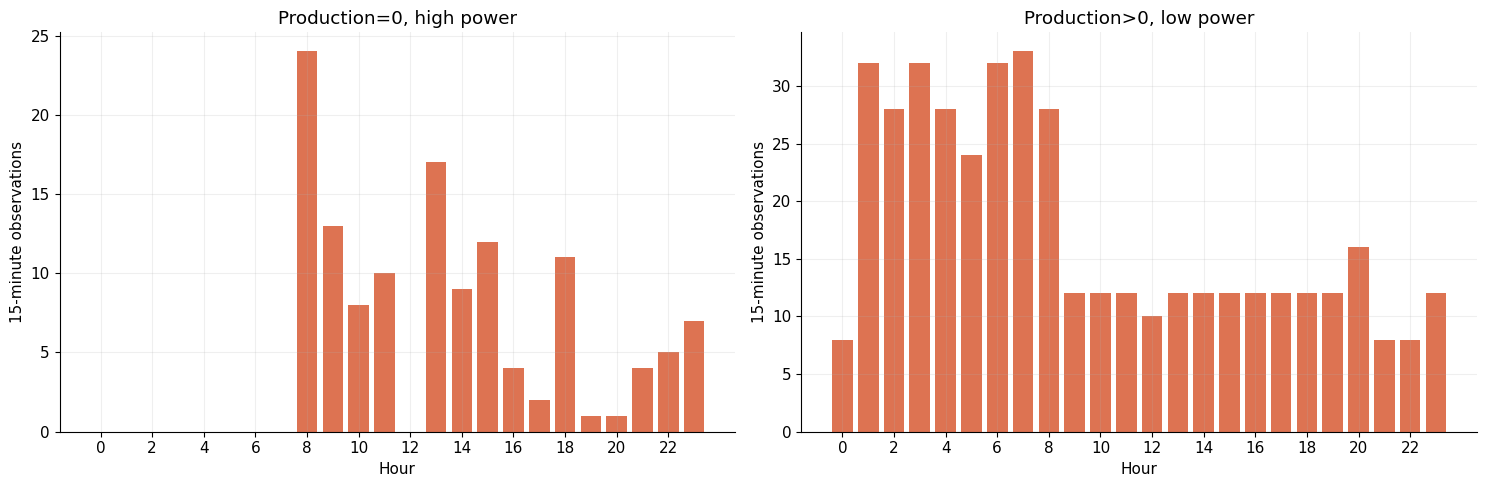


 Production=0, high power


,timestamp,power,생산량,day,hour_restored
823,2021-01-09 13:45:00,181,0,6,False
1473,2021-01-16 08:15:00,185,0,6,False
1474,2021-01-16 08:30:00,180,0,6,False
1502,2021-01-16 15:30:00,180,0,6,False
1569,2021-01-17 08:15:00,193,0,7,False
1570,2021-01-17 08:30:00,197,0,7,False
1571,2021-01-17 08:45:00,193,0,7,False
1572,2021-01-17 09:00:00,188,0,7,False
1573,2021-01-17 09:15:00,180,0,7,False
1580,2021-01-17 11:00:00,188,0,7,False


관측이 많은 날짜


,15분 관측 수
날짜,
20210328,18
20210321,18
20210314,18
20210715,17
20210117,11
20210713,11
20210130,6
20210124,6
20210301,6



 Production>0, low power


,timestamp,power,생산량,day,hour_restored
580,2021-01-07 01:00:00,26,34,4,False
581,2021-01-07 01:15:00,22,34,4,False
582,2021-01-07 01:30:00,22,34,4,False
583,2021-01-07 01:45:00,22,34,4,False
588,2021-01-07 03:00:00,22,56,4,False
589,2021-01-07 03:15:00,22,56,4,False
590,2021-01-07 03:30:00,22,56,4,False
591,2021-01-07 03:45:00,23,56,4,False
592,2021-01-07 04:00:00,22,278,4,False
593,2021-01-07 04:15:00,26,278,4,False


관측이 많은 날짜


,15분 관측 수
날짜,
20210219,64
20210226,61
20210205,57
20210121,29
20210409,29
20210128,25
20210407,25
20210420,25
20210401,21


In [21]:
case_masks = {
    "Production=0, high power": (
        quarter_data["생산량"].eq(0) & quarter_data["power"].ge(EDA_PEAK_THRESHOLD)
    ),
    "Production>0, low power": (
        quarter_data["생산량"].gt(0) & quarter_data["power"].le(LOW_POWER_THRESHOLD)
    ),
}

case_summary = []

for name, mask in case_masks.items():
    case = quarter_data.loc[mask]

    case_summary.append(
        {
            "유형": name,
            "15분 관측 수": len(case),
            "관련 시간 수": (case["timestamp"].dt.floor("h").nunique()),
            "관련 날짜 수": case["날짜"].nunique(),
            "복원 날짜 관측 수": case["hour_restored"].sum(),
        }
    )

display(pd.DataFrame(case_summary).set_index("유형"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (name, mask) in zip(axes, case_masks.items()):
    counts = (
        quarter_data.loc[mask].groupby("시간").size().reindex(range(24), fill_value=0)
    )

    ax.bar(counts.index, counts.values, color=ORANGE)

    ax.set(
        title=name,
        xlabel="Hour",
        ylabel="15-minute observations",
        xticks=range(0, 24, 2),
    )

plt.tight_layout()
save_figure(fig, "21_production_power_cases.png")

for name, mask in case_masks.items():
    print("\n", name)

    display(
        quarter_data.loc[
            mask, ["timestamp", "power", "생산량", "day", "hour_restored"]
        ].head(20)
    )

    print("관측이 많은 날짜")
    display(
        quarter_data.loc[mask]
        .groupby("날짜")
        .size()
        .sort_values(ascending=False)
        .head(10)
        .to_frame("15분 관측 수")
    )


### 셀 22. 복원 날짜 포함 여부의 민감도

고정 기준 `FIXED_PEAK_THRESHOLD = 180`으로 두 날짜 제외·복원 날짜만·전체 포함의 고전력 건수와 비율을 비교한다. 동일 기준을 사용해 날짜 포함 효과를 분리한다. 20~23시 고전력 관측 중 복원 날짜가 차지하는 부분을 확인한다.

,관측 수,고전력 관측 수,고전력 발생률(%)
범위,,,
Two dates excluded,24480,1220,4.984
Restored dates only,192,28,14.583
All dates included,24672,1248,5.058


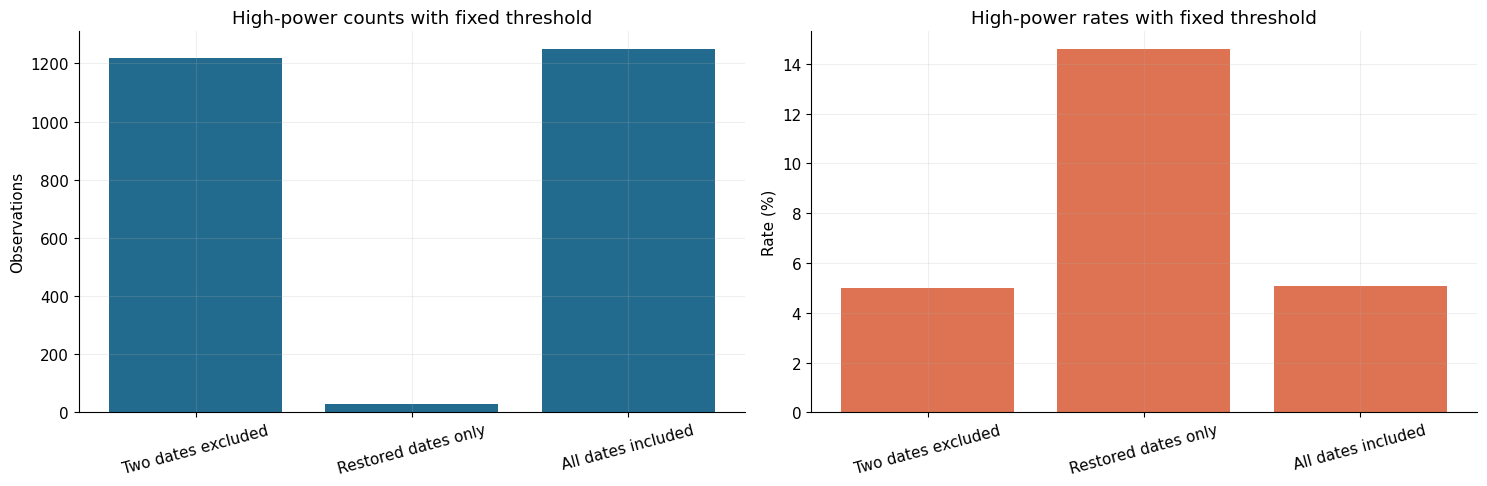

20~23시 고전력 관측: 17
그중 복원 날짜 관측: 17


,timestamp,power,생산량,hour_restored
18609,2021-07-13 20:15:00,189,0,True
18616,2021-07-13 22:00:00,187,0,True
18620,2021-07-13 23:00:00,190,0,True
18621,2021-07-13 23:15:00,188,0,True
18622,2021-07-13 23:30:00,187,0,True
18623,2021-07-13 23:45:00,188,0,True
18804,2021-07-15 21:00:00,186,0,True
18805,2021-07-15 21:15:00,188,0,True
18806,2021-07-15 21:30:00,190,0,True
18807,2021-07-15 21:45:00,185,0,True


In [22]:
quarter_data["fixed_high_power"] = quarter_data["power"].ge(FIXED_PEAK_THRESHOLD)

comparison_masks = {
    "Two dates excluded": ~quarter_data["hour_restored"],
    "Restored dates only": quarter_data["hour_restored"],
    "All dates included": pd.Series(True, index=quarter_data.index),
}

comparison_rows = []

for name, mask in comparison_masks.items():
    subset = quarter_data.loc[mask]

    comparison_rows.append(
        {
            "범위": name,
            "관측 수": len(subset),
            "고전력 관측 수": subset["fixed_high_power"].sum(),
            "고전력 발생률(%)": (subset["fixed_high_power"].mean() * 100),
        }
    )

comparison = pd.DataFrame(comparison_rows).set_index("범위")

display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(comparison.index, comparison["고전력 관측 수"], color=BLUE)
axes[0].set(title="High-power counts with fixed threshold", ylabel="Observations")

axes[1].bar(comparison.index, comparison["고전력 발생률(%)"], color=ORANGE)
axes[1].set(title="High-power rates with fixed threshold", ylabel="Rate (%)")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
save_figure(fig, "22_restoration_sensitivity.png")

# 20~23시의 고전력 출처 확인
night_high = quarter_data.loc[
    quarter_data["시간"].between(20, 23) & quarter_data["fixed_high_power"]
]

print("20~23시 고전력 관측:", len(night_high))
print("그중 복원 날짜 관측:", night_high["hour_restored"].sum())

display(night_high[["timestamp", "power", "생산량", "hour_restored"]])


## 모델링과 보고서 작성 시 활용

원본 품질 점검은 날짜·시간 복원과 결측 처리의 근거로, 시간·요일·자기상관 분석은 달력 및 과거 전력 피처를 검토하는 근거로 사용할 수 있다. 생산량 관계·0값 사례와 공장인원 파생식은 입력 변수의 의미 및 정보 누출을 점검하는 자료이다. 시간 복원 민감도는 특정 날짜가 위험 조건 분석에 미치는 영향을 보여준다.

이 EDA는 예측 정확도나 피크 저감 효과를 평가하는 실험이 아니다. 모델 성능과 경보·부하 조정 결과는 모델 노트북의 시간 순서 평가 결과에 근거하여 별도로 작성한다. 보고서의 각 표·그림에는 오류 날짜 제외 여부, 관측 단위, 고전력 기준을 명시한다.
